## Capítulo 4 - Simulação do acoplamento hidráulico-térmico
### Estudo da influência do sistema hidráulico na condutividade térmica da placa, e a influência da placa térmica na viscosidade hidráulica.



### Prefácio
Assumindo um acoplamento fraco entre ambos os sistemas estudados (one-way coupling), analisamos o impacto que a placa térmica, mantida fixa, na rede hidráulica e vice-versa.

In [1]:
# Importações!!!

import sys
import os
import importlib

root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root not in sys.path:
    sys.path.insert(0, root)

import hydraulic_thermal
import themal_hydraulics
importlib.reload(hydraulic_thermal)
importlib.reload(themal_hydraulics)
import env
importlib.reload(env)
config = env.CONFIG_HT

#### Influência da temperatura na rede hidráulica

Nesta primeira etapa do acoplamento hidráulico-térmico, investiga-se como a distribuição de temperaturas da placa afeta a viscosidade do fluido em cada aresta, sendo esta grandeza uma função da temperatura média da respectiva aresta. A temperatura média ao longo de um microcanal $k$, de comprimento $\ell_k$, é definida formalmente pela integral de linha:

$$ \langle T_k \rangle  = \frac{1}{\ell_k}\int_0^{\ell_k} T_k(p(s))\, ds $$

onde $\ell_k$ representa o comprimento da aresta e $s$ é a variável de parametrização do trajeto do microcanal (com $s=0$ no nó inicial e $s=\ell_k$ no nó final). O problema fundamental é que a função $T_k(s) = T(p(s))$ não possui expressão analítica conhecida uma vez que o campo de temperaturas é obtido numericamente pela solução do problema de condução de calor na placa, e está disponível
apenas nos nós de uma malha discreta. Por essa razão, a integral precisa ser aproximada por métodos de quadratura numérica.

A ideia central de qualquer regra de quadratura é substituir a função real $T_k(s)$, inviável de integrar analiticamente, por uma função auxiliar mais simples, como um polinômio, cuja integral é conhecida em forma fechada. Os quatro métodos explorados a seguir diferem entre si em dois aspectos independentes:

1. O grau do polinômio local usado para aproximar $T_k(s)$: grau 0 (constante) na regra do ponto médio, ou grau 1 (linear/afim) na regra do trapézio.
2. A subdivisão do domínio de integração $[0,\ell_k]$: as versões simples aplicam a aproximação polinomial em uma única vez sobre todo o intervalo, enquanto as versões compostas particionam $[0,\ell_k]$ em $N$ subintervalos de comprimento $\Delta s = \ell_k/N$ e aplicam a regra simples em cada um deles, somando as contribuições.

Assim, quanto maior o grau do polinômio interpolador e/ou maior o número de subdivisões $N$, menor tende a ser o erro de quadratura, mas maior o custo computacional associado (mais chamadas ao interpolador de temperatura). O balanço entre precisão e custo é justamente o que será investigado posteriormente.



##### Regra do ponto médio (simples)
A regra do ponto médio aproxima $T_k(s)$ por uma função **constante**, igual ao valor da temperatura no ponto médio do domínio de integração, ou seja, um polinômio interpolador de grau 0 (ordem 1) que coincide necessariamente com a função original apenas em $s = \ell_k/2$:

$$ T_k(s) \approx T_k\!\left(s = \frac{\ell_k}{2}\right) \qquad \Longrightarrow \qquad
\langle T_k \rangle  \approx  T_k\!\left(s = \frac{\ell_k}{2}\right)$$

Geometricamente, a integral é aproximada pela área de um retângulo de altura $T_k(\ell_k/2)$ e base $\ell_k$.

- Segue abaixo uma aplicação simplificada da regra do ponto médio em Python

In [2]:
# Média de temperatura pela regra do ponto_médio, assumindo que l_k = len(T_k)
def regra_do_ponto_médio(T_k: list, l_k: int):
    ponto_medio = int(l_k/2)
    return T_k[ponto_medio]

T = [36, 34, 31, 33, 31, 34, 35, 38]
T_med_pm = regra_do_ponto_médio(T, len(T))
T_med = int(sum(T)/len(T))

print(f"Temperatura média: {T_med}")
print(f"Temperatura média pela regra do ponto médio: {T_med_pm}")

Temperatura média: 34
Temperatura média pela regra do ponto médio: 31


##### Regra do ponto médio composta
A regra composta divide o intervalo $[0, \ell_k]$ em $N$ subintervalos de comprimento $\Delta s = \ell_k/N$ e aplica a regra do ponto médio simples em cada um deles, avaliando a função no centro de cada subintervalo, $s_n = \left(n - \tfrac{1}{2}\right)\Delta s$, para $n = 1, \ldots, N$. Somando as $N$ contribuições retangulares:

$$ \langle T_k \rangle \approx \frac{1}{\ell_k} \sum_{n=1}^{N} T_k(s_n)\, \Delta s $$

Cada subintervalo contribui com sua própria aproximação constante local; à medida que $N$ cresce, os subintervalos ficam cada vez menores e a função $T_k$ pode ser considerada aproximadamente constante dentro de cada um deles com erro cada vez menor. Teoricamente, o erro global da regra do ponto médio composta decai como $O(\Delta s^2) = O(1/N^2)$ para funções suficientemente
suaves. Essa é a razão pela qual métodos compostos são preferíveis a uma única avaliação simples sempre que se exige maior exatidão: o custo cresce apenas linearmente com $N$ (uma avaliação da função por subintervalo), enquanto o erro decai quadraticamente.

- Segue abaixo uma aplicação simplificada da regra do ponto médio composta em Python

In [10]:
# Média de temperatura pela regra do ponto_médio composta, assumindo que l_k = len(T_k)
def regra_do_ponto_médio_composta(T_k: list, l_k: int, N):
    delta_s = l_k/N
    t_sum = 0

    for n in range(1, N+1):
        s_n = int((n - 0.5)*delta_s)
        t_sum += T_k[s_n]*delta_s

    return t_sum/l_k

T = [36, 34, 31, 33, 31, 34, 35, 38]
T_med_pmc_2 = regra_do_ponto_médio_composta(T, len(T), 2)
T_med_pmc_4 = regra_do_ponto_médio_composta(T, len(T), 4)
T_med = int(sum(T)/len(T))

print(f"Temperatura média: {T_med}")
print(f"Temperatura média pela regra do ponto médio composta (N=2): {T_med_pmc_2}")
print(f"Temperatura média pela regra do ponto médio composta (N=4): {T_med_pmc_4}")

Temperatura média: 34
Temperatura média pela regra do ponto médio composta (N=2): 33.0
Temperatura média pela regra do ponto médio composta (N=4): 34.75



##### Regra do trapézio (simples)
A regra do trapézio aproxima $T_k(s)$ por uma função linear que conecta os dois valores extremos do intervalo, sendo assim um polinômio interpolador de grau 1 que coincide com a função original em $s=0$ e $s=\ell_k$:

$$ \langle T_k \rangle \approx \frac{1}{2}(T_k(\ell_k)+ T_k(0)), \qquad T_k(s) \approx T_k(0) + \frac{s}{\ell_k} (T_k(\ell_k)- T_k(0)) $$

Geometricamente, a integral é aproximada pela área do trapézio formado pelos pontos $(0, T_k(0))$, $(\ell_k, T_k(\ell_k))$ e o eixo $s$. Uma vez que a regra do trapézio simples depende exclusivamente dos dois valores de fronteira, ignorando completamente o comportamento da função no interior do intervalo, ela se torna particularmente vulnerável quando os pontos extremos não são representativos do comportamento médio da função, por exemplo, quando ambos os valores de fronteira estão do mesmo lado da média, ou quando há concavidade pronunciada no interior do domínio

- Segue abaixo uma aplicação simplificada da regra do trapézio em Python

In [4]:
# Média de temperatura pela regra do trapézio, assumindo que l_k = len(T_k)
def regra_do_trapézio(T_k: list, l_k: int):
    return 0.5*(T_k[l_k-1] + T_k[0])

T = [36, 34, 31, 33, 31, 34, 35, 38]
T_med_t = regra_do_trapézio(T, len(T))
T_med = int(sum(T)/len(T))

print(f"Temperatura média: {T_med}")
print(f"Temperatura média pela regra do trapézio: {T_med_t}")

Temperatura média: 34
Temperatura média pela regra do trapézio: 37.0


##### Regra do trapézio composta
Analogamente ao caso do ponto médio, a regra do trapézio composta subdivide $[0, \ell_k]$ em $N$ subintervalos de comprimento $\Delta s = \ell_k/N$, com nós $s_n = n\, \Delta s$, $n = 0, 1, \ldots, N$, e aplica a regra do trapézio simples em cada subintervalo. Ao somar as áreas dos $N$ trapézios, os pontos internos $s_1, \ldots, s_{N-1}$ acabam sendo contados duas vezes (uma vez como extremo direito de um subintervalo, outra como extremo esquerdo do próximo), o que leva à conhecida fórmula composta:

$$\langle T_k \rangle \approx \frac{1}{N} \left[ \frac{T_k(0) + T_k(\ell_k)}{2} + \sum_{n=1}^{N-1} T_k(s_n) \right]$$

Na qual apenas os dois nós de fronteira recebem peso $1/2$, e todos os nós internos recebem peso unitário. Assim como a regra do ponto médio composta, o erro global da regra do trapézio composta decai como $O(\Delta s^2) = O(1/N^2)$.

- Segue abaixo uma aplicação simplificada da regra do trapézio composta em Python

In [12]:
# Média de temperatura pela regra do ponto_médio composta, assumindo que l_k = len(T_k)
def regra_do_trapézio_composta(T_k: list, l_k: int, N):
    delta_s = l_k/N
    t_sum = 0.5*(T_k[l_k-1] + T_k[0])/N
    
    for n in range(1, N):
        s_n = int(n*delta_s)
        t_sum += T_k[s_n]/N

    return t_sum

T = [36, 34, 31, 33, 31, 34, 35, 38]
T_med_tc_2 = regra_do_trapézio_composta(T, len(T), 2)
T_med_tc_4 = regra_do_trapézio_composta(T, len(T), 4)
T_med = int(sum(T)/len(T))

print(f"Temperatura média: {T_med}")
print(f"Temperatura média pela regra do trapézio composta (N=2): {T_med_tc_2}")
print(f"Temperatura média pela regra do trapézio composta (N=4): {T_med_tc_4}")

Temperatura média: 34
Temperatura média pela regra do trapézio composta (N=2): 34.0
Temperatura média pela regra do trapézio composta (N=4): 33.5


Comparando os quatro métodos lado a lado para o vetor de exemplo T nos excertos de código acima, nota-se que as versões compostas convergem rapidamente para a média verdadeira, independentemente de qual regra local (ponto médio ou trapézio) tenha sido usada como base, reforçando que a subdivisão do domínio é o fator dominante na redução do erro, ainda mais do que a escolha entre polinômio de grau 0 ou grau 1. Essa conclusão qualitativa, obtida aqui com um vetor extremamente simplificado, será quantificada na aplicação real ao campo de temperaturas da placa, nas seções seguintes.


##### O cálculo da temperatura
Nos excertos de código acima, sempre se assumiu que o comprimento $\ell_k$ era o tamanho do vetor $T_k$, o que representava a temperatura precisa ao longo de cada aresta. Entretanto, por causa da discretização numérica da placa térmica, não se tem a temperatura exatamente ao longo dos canais, conhecendo apenas nos nós da malha computacional usada para resolver o problema de condução de calor, que em geral não coincidem com as coordenadas $p(s)$ por onde passam as arestas da rede hidráulica. Foi, portanto, necessário empregar um interpolador bidimensional para estimar as temperaturas em qualquer coordenada arbitrária do domínio $[0,L_x]\times[0,L_y]$.

Em Python, usa-se a função `RegularGridInterpolator` do `scipy.interpolate`, que permite construir um interpolador bidimensional com diferentes níveis de suavidade, dependendo do método escolhido:

- nearest: interpolação de ordem 0, que atribui ao ponto de interesse o valor do nó de malha geometricamente mais próximo, gerando um campo com descontinuidades nas fronteiras entre células.
- linear: interpolação de ordem 1, que constrói um polinômio linear local a partir dos quatro nós vizinhos, garantindo continuidade do campo interpolado, mas não de suas derivadas.
- cubic: interpolação polinomial de ordem superior (grau 3), que utiliza uma vizinhança maior de nós para construir um polinômio mais suave, com continuidade também das derivadas produzindo tipicamente os contornos visualmente mais suaves entre os três métodos, ao custo de maior complexidade computacional.

Naturalmente, quando o interpolador é avaliado exatamente em um nó da malha original, os três métodos retornam o mesmo valor (a temperatura nodal). A diferença entre eles só se manifesta em pontos intermediários, e tende a ser mais pronunciada em malhas grosseiras e em regiões de gradiente de temperatura acentuado, como nas vizinhanças das regiões com condição de contorno impostas.

Os resultados da nossa aplicação do interpolador bidimensional seguem abaixo. Comparou-se o que acontece ao usar os diferentes métodos de interpolação (nearest, linear e cubic) e ao usar duas malhas térmicas de resolução distinta (uma grosseira e uma refinada).


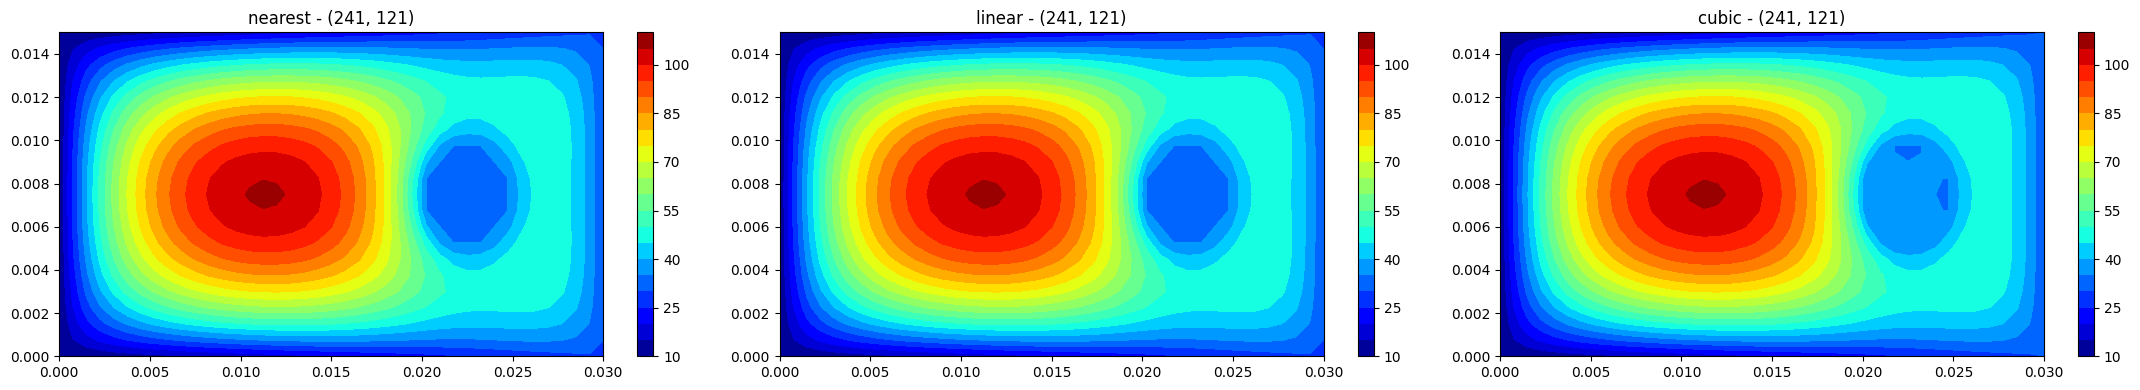

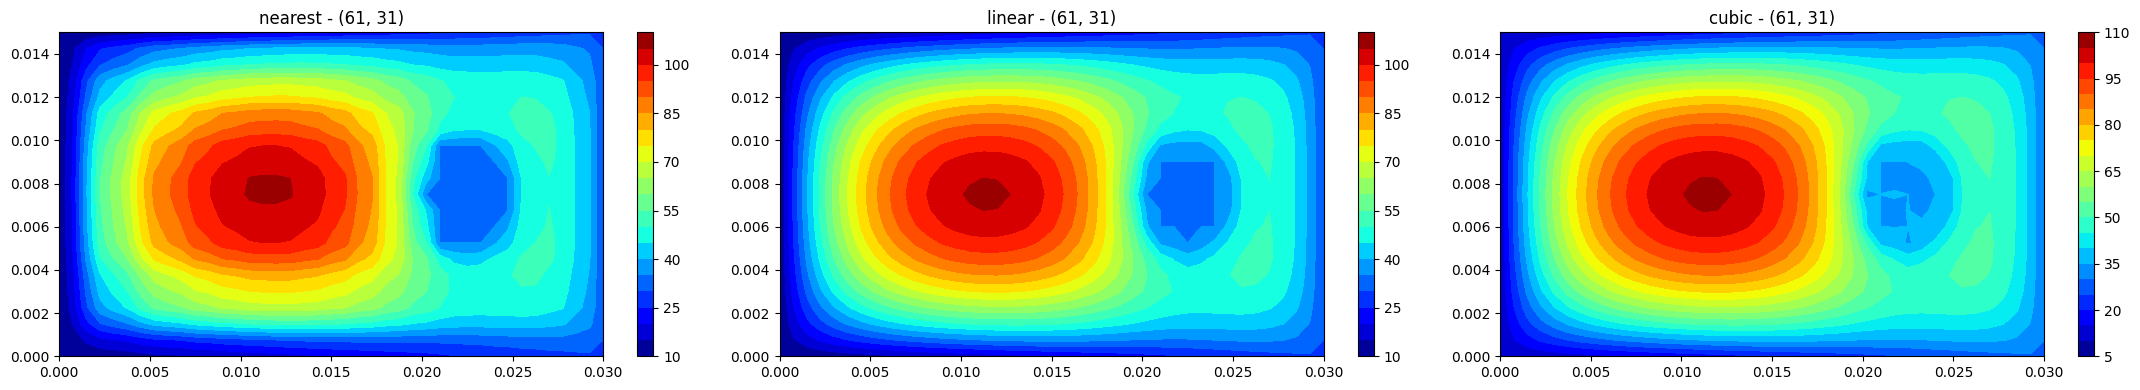

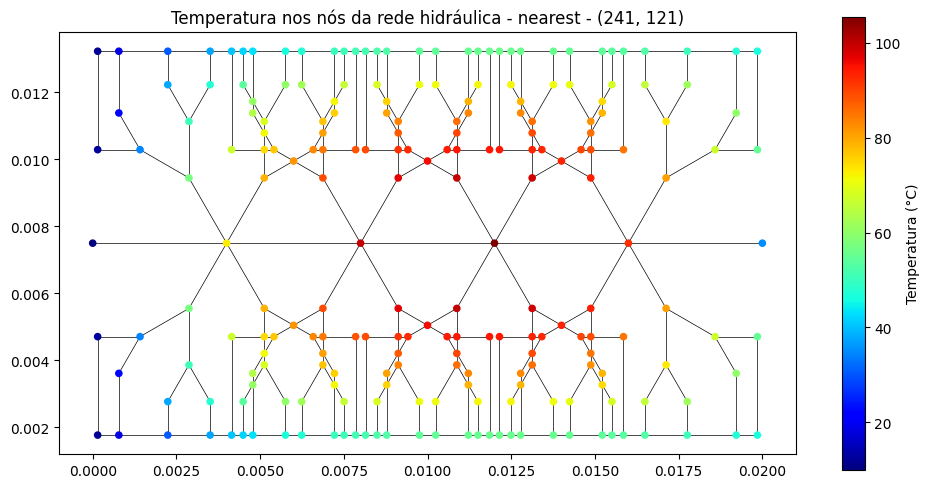

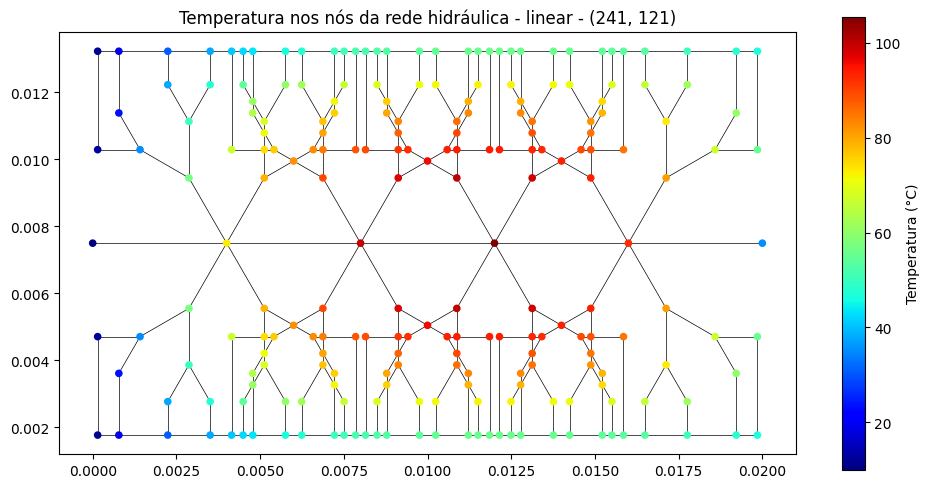

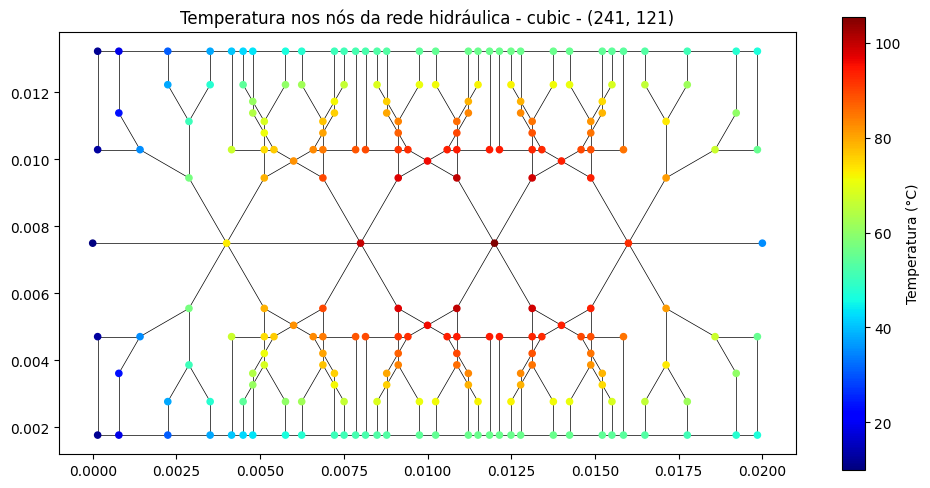

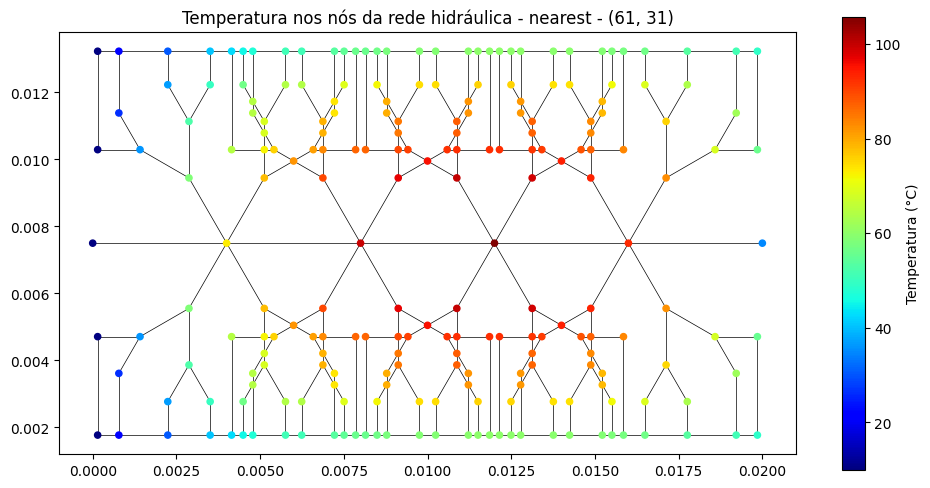

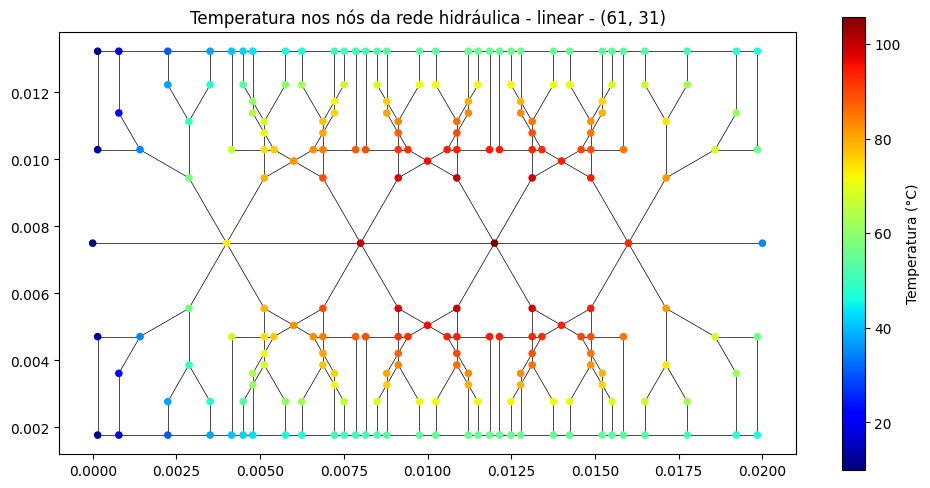

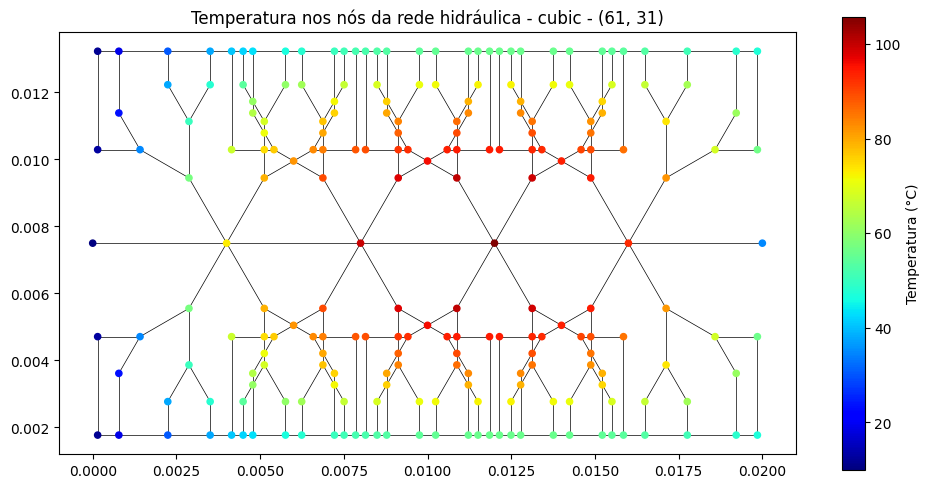

In [5]:
thermal_to_hydraulic = hydraulic_thermal.HydraulicThermal(config)
thermal_to_hydraulic.run_interpolator(plot=True)

Comparando visualmente os três métodos de interpolação, observa-se o padrão esperado a partir da teoria: o método nearest produz um campo em blocos, com contornos visivelmente serrilhados e descontinuidades abruptas nas fronteiras entre células da malha uma consequência inevitável de uma interpolação de ordem 0. Já os métodos linear e cubic produzem contornos suaves e visualmente muito próximos entre si, com o cubic suavizando ligeiramente mais as regiões de maior curvatura do campo (por exemplo, ao redor da inclusão circular, onde o gradiente de temperatura é mais acentuado).

O efeito da resolução da malha térmica é ainda mais evidente do que o efeito do método de interpolação em si: na malha grosseira, até mesmo os métodos linear e cubic apresentam contornos com curvatura menos fiel à física do problema (a informação geométrica precisa simplesmente não está disponível nos nós), enquanto na malha refinada os três métodos convergem visualmente para resultados praticamente indistinguíveis, exceto pela já mencionada descontinuidade do nearest. 

A partir do interpolador montado, calculamos a temperatura média em cada aresta da rede usando as quatro regras de quadratura discutidas acima variando o número de subdivisões $N \in \{1, 10, 100, 1000\}$. Como a solução analítica contínua de $T_k(s)$ ao longo dos canais não é conhecida (apenas o campo interpolado a partir da malha térmica), utiliza-se a solução com $N=1000$ subdivisões como uma referência assintótica de alta exatidão, comparando-se a ela os resultados obtidos com $N$ menores. Isso permite estimar, de forma prática, tanto o erro de integração cometido em cada configuração quanto o tempo de computação associado, o que evidencia o balanço entre precisão e custo discutido anteriormente.


 ESTRATÉGIA MATEMÁTICA PARA ESTIMATIVA DE ERRO DE INTEGRAÇÃO
Como a solução analítica contínua da temperatura ao longo dos canais é desconhecida,
adotou-se a solução altamente refinada com N = 1000 subintervalos como nossa
Referência Assintótica Exata de controle (<T_k>_ref).

O erro de integração cometido em cada cenário (N = 1, 10, 100) foi estimado através
do Erro Absoluto Máximo Global (Norma do Infinito) sobre todas as arestas da rede:

      E_max^(N) = max_k | <T_k>^(N) - <T_k>^(N=1000) |

Onde k representa o índice de cada aresta e <T_k> é a temperatura média calculada.

Regra de Integração  | Subdiv. (N)  | Tempo Exec. (s) | Erro Máx. Estimado
Ponto Médio          | 1            | 0.000423        | 3.2883e+00 °C     
Ponto Médio          | 10           | 0.002000        | 2.0233e-02 °C     
Ponto Médio          | 100          | 0.014203        | 2.0034e-04 °C     
Ponto Médio          | 1000         | 0.157011        | --- (Ref. Exata)  
Trapézio             | 1            | 

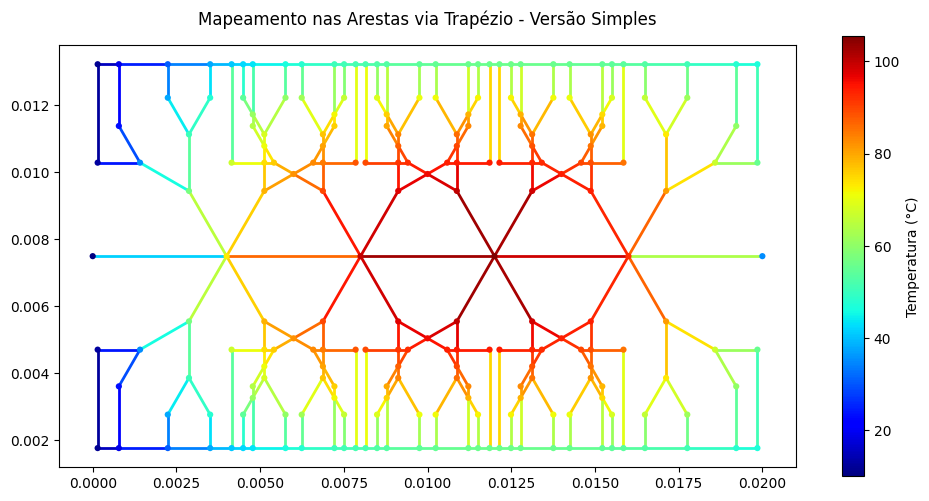

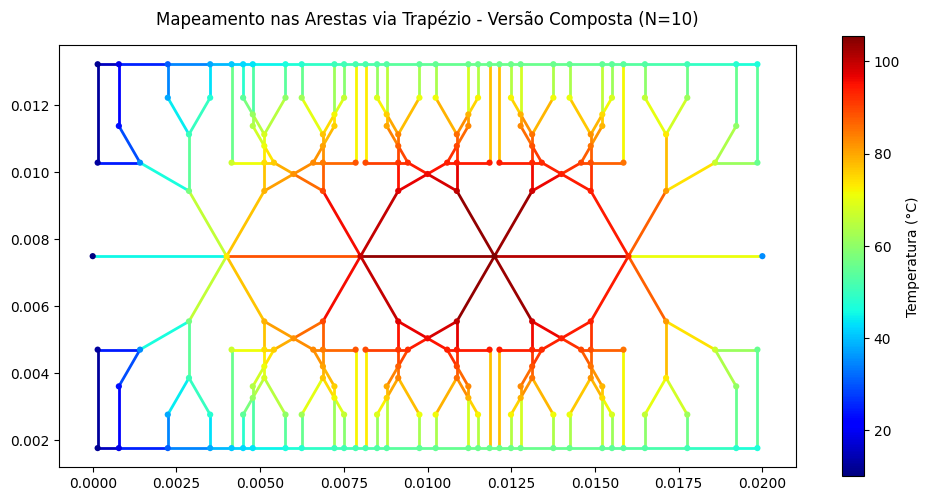

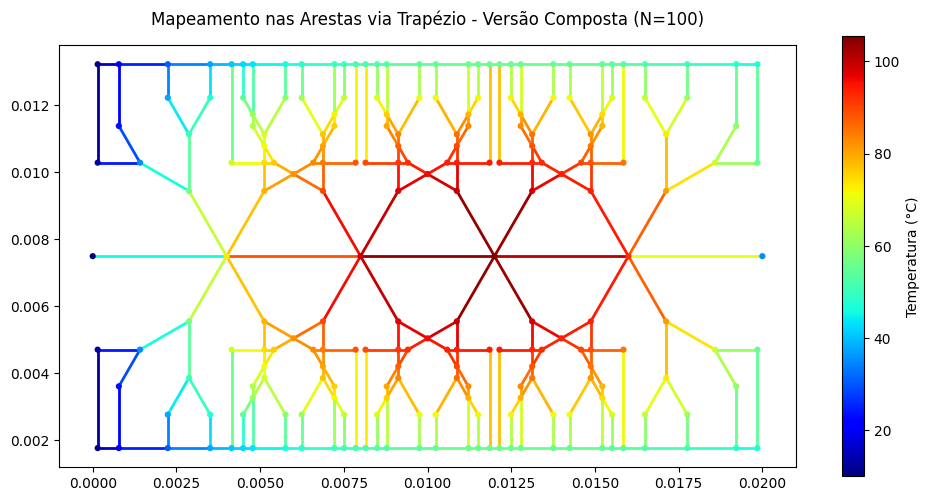

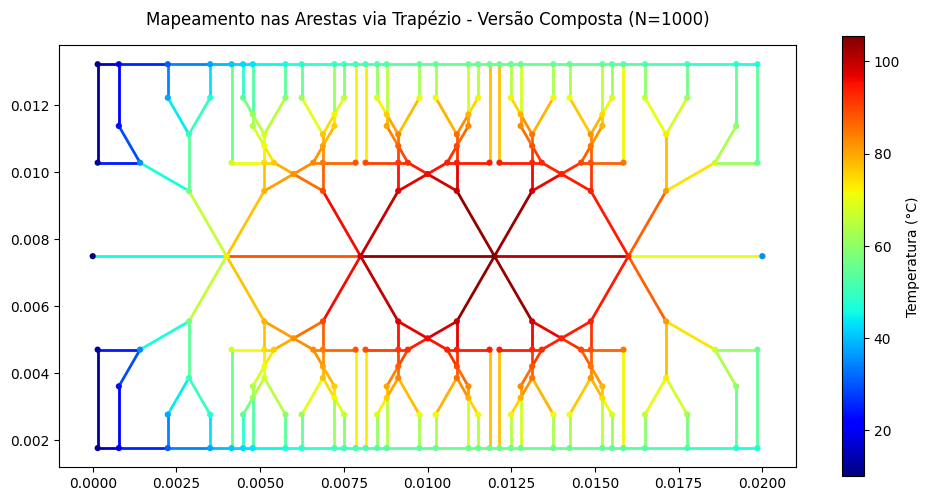

In [6]:
thermal_to_hydraulic.evaluate_coupling(plot=True)

A tabela evidencia claramente o comportamento teórico esperado das regras de quadratura. Analisando a razão entre erros sucessivos ao aumentar $N$ por um fator de 10:

- Ponto médio: o erro cai de $3{,}29\,$ ($N=1$) para $2{,}02\times10^{-2}\,$ ($N=10$) e para $2{,}00\times10^{-4}\,$ ($N=100$), o que configura uma razão de aproximadamente 163x e depois 101x, respectivamente.

- Trapézio: o erro cai de $7{,}63\,$ para $4{,}05\times10^{-2}\,$ e para $4{,}01\times10^{-4}\,$, uma razão de aproximadamente 189x e depois 101x.

A razão próxima de 100x ao aumentar $N$ por um fator de $10$ confirma experimentalmente a convergência quadrática, $O(1/N^2)$, prevista pela teoria para ambas as regras compostas.

Além disso, comparando as duas regras para um mesmo $N$, o erro do trapézio é sistematicamente cerca de **duas vezes maior** que o erro do ponto médio ($7{,}63/3{,}29 \approx 2{,}32$ em $N=1$; $4{,}05/2{,}02 \approx 2{,}00$ em $N=10$; $4{,}01/2{,}00 \approx 2{,}00$ em $N=100$), o que mostra que a regra do ponto médio é a opção mais eficiente entre as duas para este problema.

Do ponto de vista de custo computacional, o tempo de execução cresce de forma aproximadamente linear com $N$ (por exemplo, para o ponto médio: $0{,}0004\,\text{s} \to 0{,}0020\,\text{s} \to 0{,}0142\,\text{s} \to 0{,}1570\,\text{s}$ para $N = 1, 10, 100, 1000$), como esperado, já que cada subdivisão adicional exige uma nova avaliação do interpolador de temperatura. Combinando precisão e custo, $N=100$ já oferece um erro da ordem de $10^{-4}\,$ a um custo de apenas ~14 ms por configuração, tornando-se um excelente ponto de operação: refinar até $N=1000$ traz uma melhoria de precisão que, na prática, não se traduz em nenhuma mudança perceptível nas variáveis hidráulicas globais (pressão e potência), como será visto a seguir.


Conhecendo a temperatura média de cada canal, foi possível resolver o circuito hidráulico da rede, atualizando a condutância de cada aresta $C_k = \kappa_k/L_k$ para levar em conta a viscosidade $\mu(\langle T_k \rangle)$ na hora de montar o sistema linear. Avalia-se, a seguir, de que maneira a escolha da malha térmica (grosseira *vs.* refinada) e da regra de quadratura (incluindo o número de subdivisões $N$) se propagam para as variáveis hidráulicas globais de interesse: a pressão máxima da rede e a potência total dissipada pelo escoamento.

In [7]:
thermal_to_hydraulic.avaliar_impacto_malha_e_quadratura()


 AVALIAÇÃO QUANTITATIVA DO ACOPLAMENTO TERMO-HIDRÁULICO
Malha Térmica        | Regra        | Subdiv. (N)  | Pressão Máx (Pa)   | Potência Total (W)
-------------------------------------------------------------------------------------
Grosseira            | Ponto Médio  | 1            | 1819.29            | 0.001927          
Grosseira            | Ponto Médio  | 10           | 1839.19            | 0.001949          
Grosseira            | Ponto Médio  | 100          | 1839.46            | 0.001950          
Grosseira            | Ponto Médio  | 1000         | 1839.46            | 0.001950          
Grosseira            | Trapézio     | 1            | 1892.87            | 0.002009          
Grosseira            | Trapézio     | 10           | 1840.01            | 0.001950          
Grosseira            | Trapézio     | 100          | 1839.46            | 0.001950          
Grosseira            | Trapézio     | 1000         | 1839.46            | 0.001950          
Refinada            

Tomando o resultado com $N=1000$ como referência convergida para cada combinação de malha/regra, observa-se que a escolha de $N$ deixa de importar a partir de $N \gtrsim 10$: Na malha grosseira, a regra do ponto médio com $N=1$ subestima a pressão máxima em cerca de $1{,}1\%$ ($1819{,}29$ Pa vs. $1839{,}46$ Pa convergidos), enquanto a regra do trapézio com $N=1$ superestima a pressão em cerca de $2{,}9\%$ ($1892{,}87$ Pa). Na malha refinada, o mesmo padrão se repete e se intensifica: $-1{,}8\%$ para o ponto médio simples e $+4{,}5\%$ para o trapézio simples. Já a partir de $N=10$, ambas as regras já concordam com a referência com menos de $0{,}1\%$ de desvio, confirmando que poucas subdivisões já são suficientes para garantir a exatidão das grandezas hidráulicas globais, mesmo que a integral de cada aresta isolada ainda não esteja plenamente convergida.

Nota-se também que a escolha da malha térmica tem um impacto maior do que a escolha da regra de quadratura. Comparando os valores plenamente convergidos ($N=1000$) entre a malha grosseira e a malha refinada, a pressão máxima sobe de $1839{,}46$ Pa para $1929{,}50$ Pa, um aumento de  aproximadamente $4{,}9\%$, e a potência total segue a mesma tendência proporcional ($0{,}00195$ W $\to$ $0{,}00205$ W). Como a viscosidade do fluido, $\mu(T)$, é uma função decrescente da temperatura, uma pressão máxima mais alta na malha refinada é consistente com uma viscosidade média efetivamente maior ao longo dos canais, ou seja, a malha térmica refinada está associando aos canais, em média, temperaturas mais baixas do que a malha grosseira, cujo processo de interpolação a partir de poucos nós tende a suavizar (e nivelar) picos e vales do campo de temperatura em direção a um valor médio mais ameno. Esse resultado reforça que o refinamento da malha térmica é o fator com maior peso a se investir computacionalmente, mais do que a escolha entre ponto médio e trapézio ou o número de subdivisões acima de $N \approx 10$.


##### Discussão complementar: média de temperatura *vs.* média de viscosidade
 
- O Problema da Abordagem Clássica
 
A abordagem tradicionalmente adotada consiste em calcular a temperatura média $\langle T_k \rangle$ da aresta e avaliar a viscosidade uma única vez nesse valor médio: $\mu(\langle T_k \rangle)$. No entanto, a viscosidade dinâmica da água é descrita por uma relação não linear com a temperatura:
 
$$\mu(T) = \frac{0.001791}{1 + 0.03368\,T + 0.000221\,T^2} $$
 
- Abordagem Proposta: Integração Direta
 
Em vez de avaliar a média da temperatura e aplicar a lei constitutiva, propõe-se calcular a viscosidade local em cada ponto de discretização e então obter o seu valor médio integrado na aresta:
 
$$\langle \mu_k \rangle = \frac{1}{\ell_k} \int_0^{\ell_k} \mu\!\left(T_k(p(s))\right) ds $$
 
Numericamente, aplicando a Regra do Trapézio composta, obtemos:
 
$$\langle \mu_k \rangle \approx \frac{1}{N} \sum_{n=1}^{N} \mu\!\left(T_k(s_n)\right) $$
 


#### Influência dos microcanais na placa térmica

Observando agora o efeito inverso do acoplamento, a influência da rede hidráulica sobre a placa térmica, a rede de microcanais impacta o comportamento térmico da placa por meio de dois mecanismos físicos distintos, que serão investigados separadamente sob a hipótese de acoplamento fraco (o campo de pressão/vazão da rede permanece fixo enquanto se resolve o problema térmico):

1. Modificação da condutividade térmica: na vizinhança dos canais, o material ao redor de um microcanal de qualquer material com maior condutividade que o da placa tende a conduzir calor mais eficientemente que o restante da placa.
2. Introdução de um termo fonte (geração) ou sumidouro (extração) de calor: cenário associado a trocas de calor do fluido com a placa ao longo do trajeto do canal.

##### Influência na condutividade

Para incorporar o primeiro mecanismo, é necessário identificar quais arestas da rede hidráulica se encontram geometricamente próximas de cada ponto onde a condutividade da placa precisa ser avaliada durante a montagem da matriz do sistema linear de condução de calor. Como a condutividade térmica é o parâmetro central na definição dos fluxos, para cada nó $(i,j)$ da malha o coeficiente $k$ deve ser estimado nas quatro posições de interface (oeste, leste, sul, norte) que circundam o volume de controle.

Adota-se a premissa física de que apenas os microcanais posicionados dentro de um raio de corte $d_{max}$ em relação ao ponto de interesse exercem influência sobre a condutividade local. Como tanto a malha de discretização da placa quanto a rede hidráulica podem conter milhares de nós e arestas, essa busca espacial (encontrar, para cada ponto da grade, quais arestas da rede estão a uma distância menor que $d_{max}$) precisa ser implementada de forma computacionalmente eficiente que evita o custo de uma busca por força bruta $O(N_{grade}\times N_{arestas})$.

Uma vez mapeadas as arestas vizinhas de cada face, a condutividade térmica modificada na face $f$ é calculada como:

$$ k_f = k_0 \left(1 + \sum_{j \in \mathcal{V}_f} \frac{1}{1+d_j}\right) $$

onde $k_0 = 0{,}25\;\text{W}\cdot\text{K}^{-1}\cdot\text{m}^{-1}$ é a condutividade nominal do material original da placa, $\mathcal{V}_f$ é o conjunto de todas as arestas da rede que se encontram na vizinhança (dentro do raio $d_{max}$) do ponto médio da face $f$, e $d_j$ é a menor distância euclidiana entre esse ponto médio e a $j$-ésima aresta vizinha. Note que, como cada termo $1/(1+d_j)$ é estritamente positivo, a presença de microcanais sempre aumenta a condutividade local em relação ao valor nominal $k_0$, e esse aumento é tanto maior quanto mais próximos (menor $d_j$) e mais numerosos forem os canais dentro do raio de
corte. Consequentemente, espera-se que aumentar $d_{max}$ amplie tanto a região espacial afetada (mais pontos da grade passam a enxergar pelo menos um canal próximo) quanto a magnitude do reforço de condutividade em cada ponto (mais arestas entram na soma $\mathcal{V}_f$ simultaneamente), suavizando gradualmente a transição entre a região "canalizada" (condutividade efetiva elevada) e o substrato original.

Também imagina-se que refinar a malha computacional da placa permita resolver com mais fidelidade geométrica a extensão espacial exata dessa região de condutividade aumentada, já que malhas grosseiras podem tanto "perder" canais estreitos que caem entre dois nós consecutivos quanto atribuir uma influência artificialmente larga a canais que, na realidade, afetam apenas uma vizinhança estreita.

Segue abaixo a aplicação da rotina que calcula a condutividade modificada e resolve o problema térmico resultante, variando o raio de corte $d_{max} \in \{0{,}00025,\ 0{,}0005,\ 0{,}001\}\,$ e a malha computacional entre $(61,31)$, $(121,61)$ e $(241,121)$ pontos.


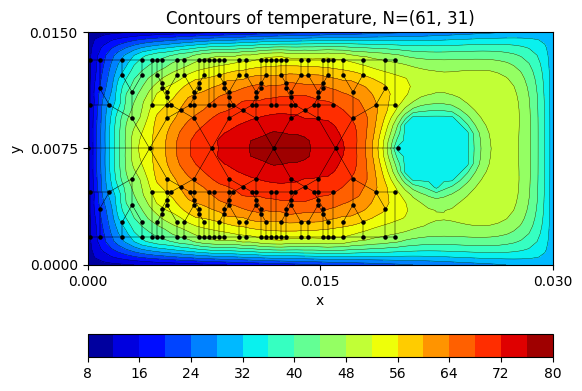

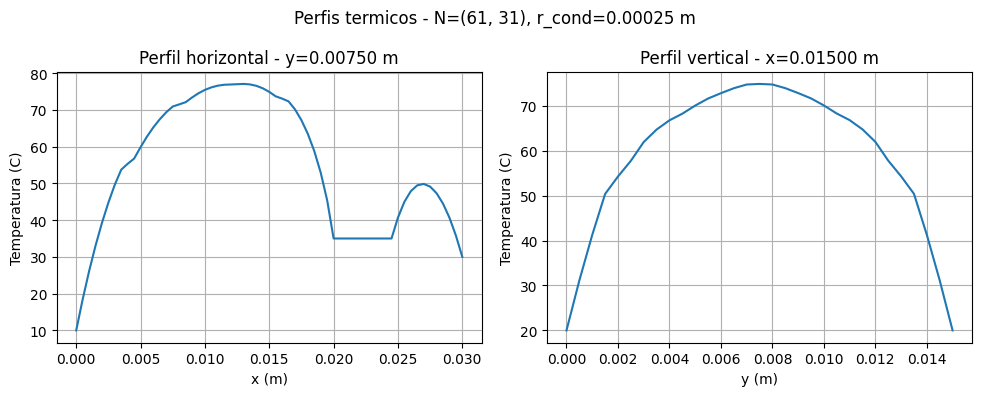

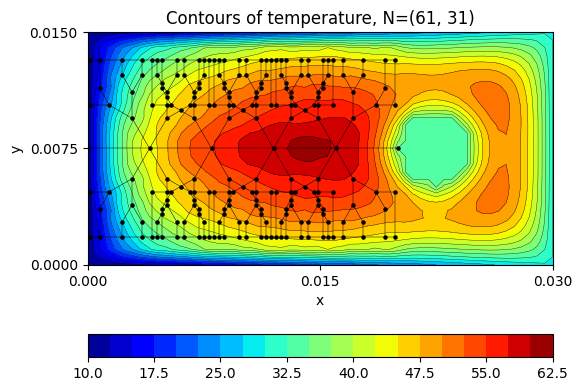

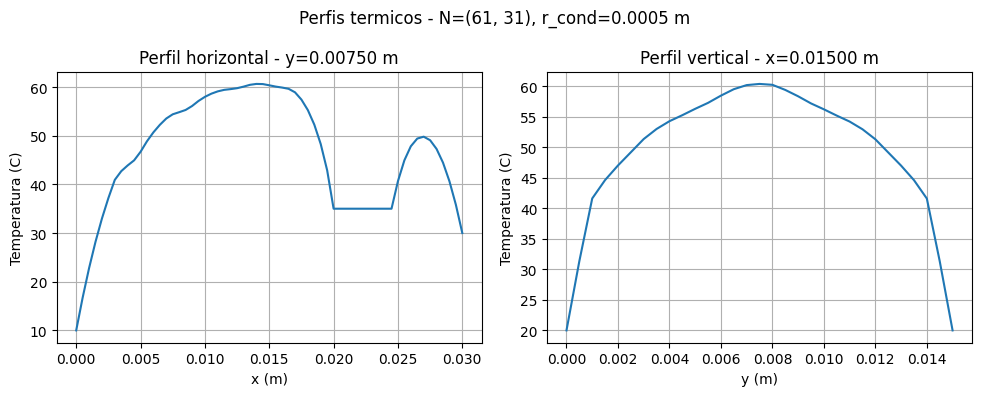

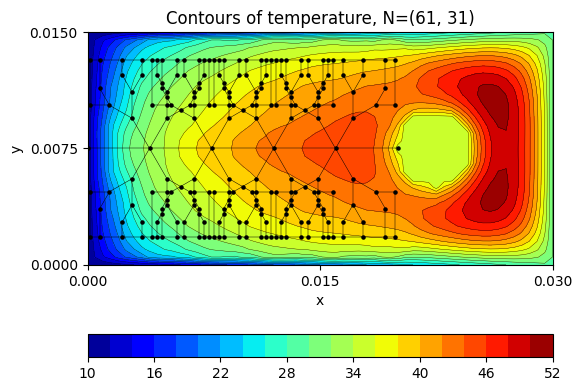

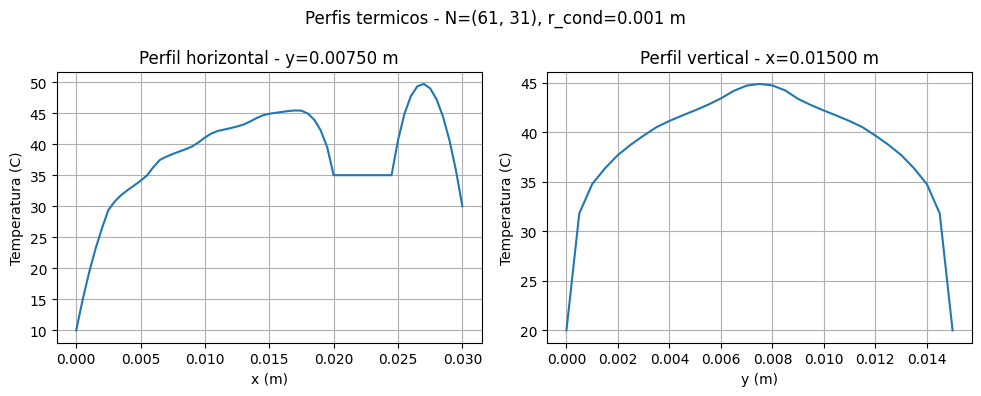

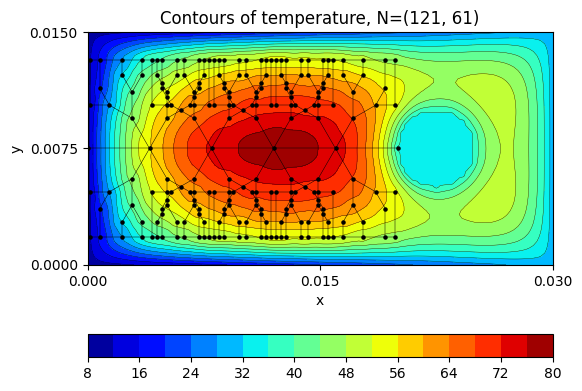

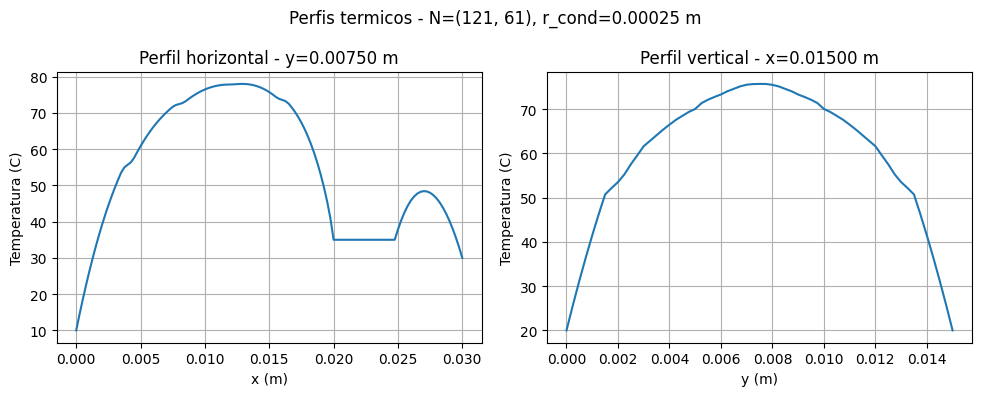

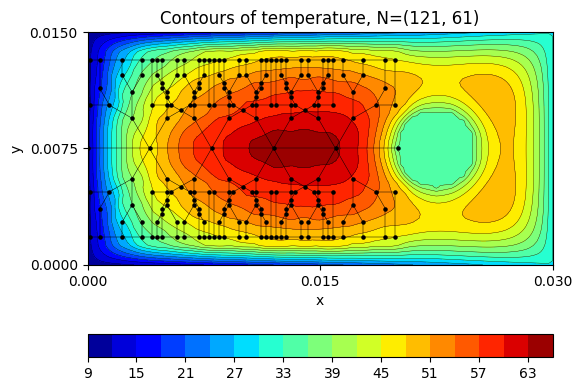

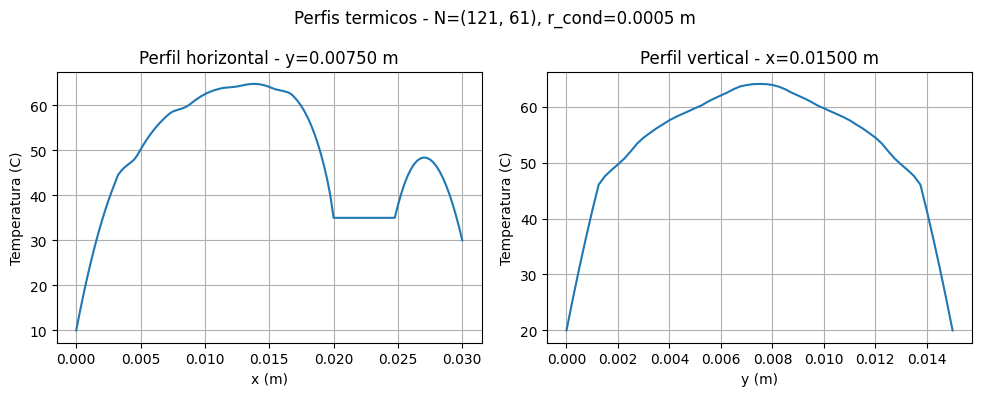

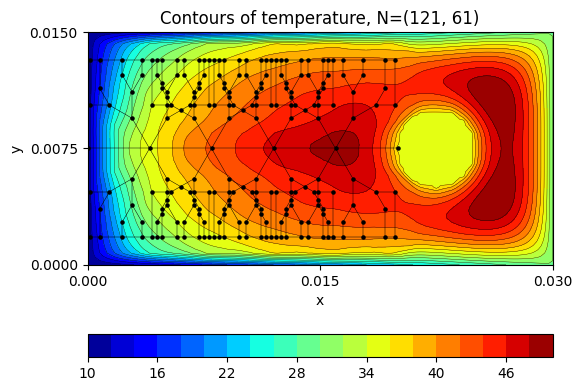

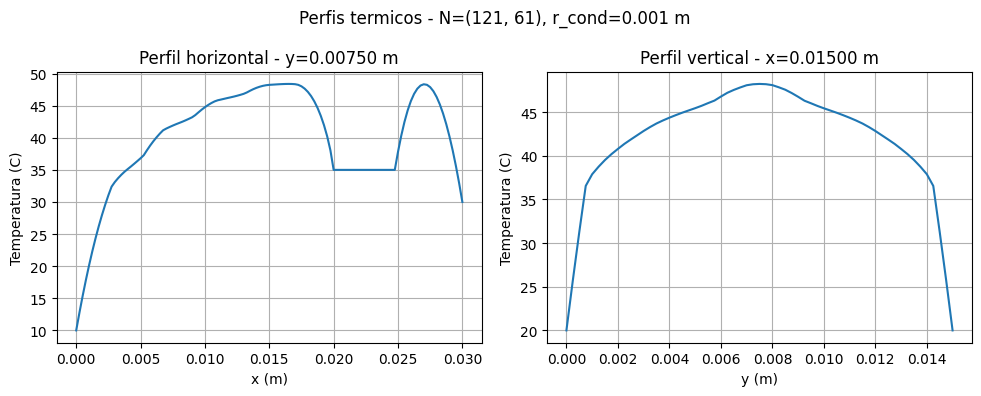

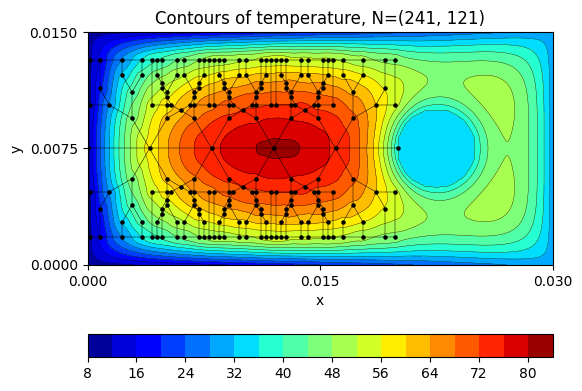

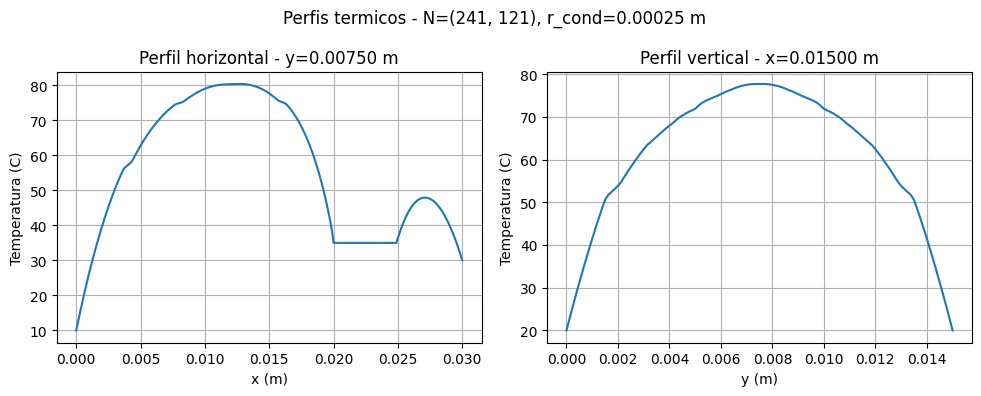

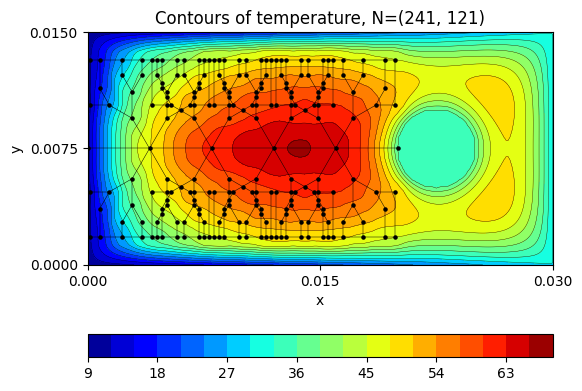

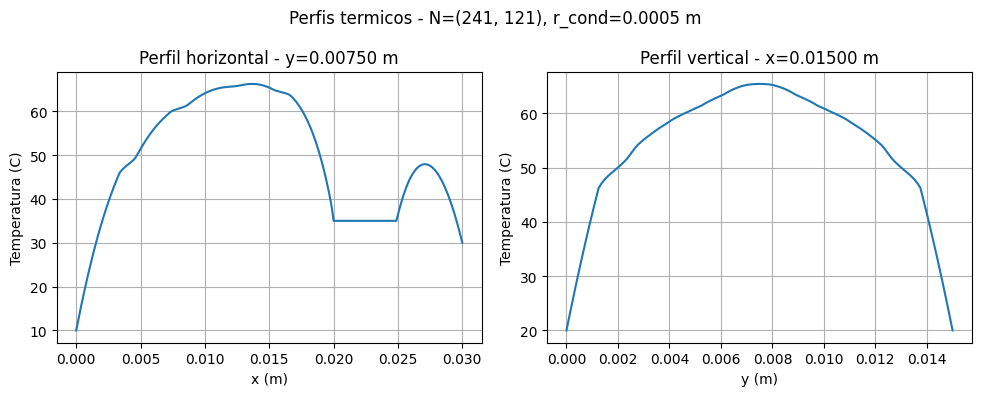

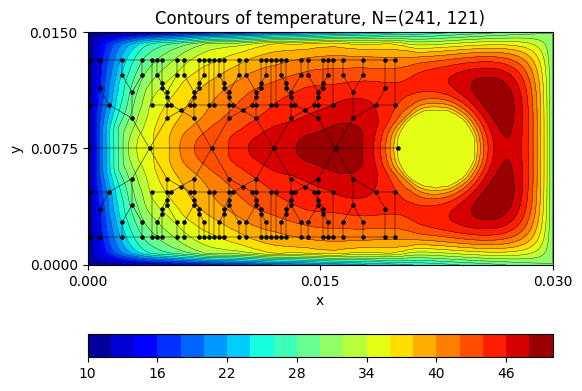

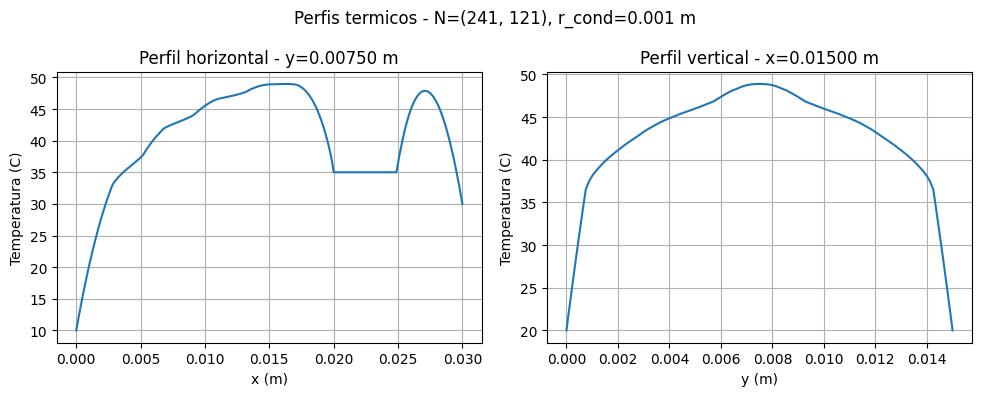


RESULTADOS - PROBLEMA 1 / PARTE 2

    Nx     Ny   r_cond (m)     Tmax (C)  k_faces (s) assembly (s)  solve (s)  total (s)
----------------------------------------------------------------------------------------
    61     31      0.00025      77.0438       0.0585       0.0040     0.0025     0.0650
    61     31       0.0005      60.6347       0.0550       0.0039     0.0025     0.0614
    61     31        0.001      50.9357       0.0858       0.0037     0.0024     0.0919
   121     61      0.00025      77.9849       0.1113       0.0134     0.0117     0.1364
   121     61       0.0005      64.7352       0.1642       0.0132     0.0114     0.1888
   121     61        0.001      49.8410       0.3138       0.0132     0.0117     0.3388
   241    121      0.00025      80.4229       0.4132       0.0525     0.0744     0.5401
   241    121       0.0005      66.2396       0.6714       0.0529     0.0767     0.8010
   241    121        0.001      49.5113       1.4194       0.0537     0.0754     1.

In [18]:
hydraulic_to_thermal = hydraulic_thermal.Hydraulic_to_Thermal(config)
hydraulic_to_thermal.run_problem1(plot= True, print_info=True);


Os mapas de contorno e os perfis unidimensionais gerados para as nove combinações de raio de corte e malha computacional confirmam a tendência prevista: quanto maior o raio de corte $d_{max}$, mais larga e mais intensa é a região de condutividade elevada ao redor de cada canal, já que mais arestas passam a contribuir simultaneamente para a soma $\sum_j 1/(1+d_j)$ em cada face avaliada (o
padrão de "auréola" de alta condutividade em torno da rede se torna visivelmente mais espesso ao se comparar $d_{max}=0{,}00025$ m com $d_{max}=0{,}001$ m). Como a condutividade mais alta favorece a difusão de calor para fora das regiões mais quentes, o efeito líquido esperado é uma leve redução do pico de temperatura e um perfil termicamente mais uniforme (menos escarpado) nas seções transversais que cruzam a vizinhança dos canais, à medida que $d_{max}$ cresce.

Quanto ao refinamento espacial da malha, o efeito observado é mais sutil: em malhas grosseiras $(61,31)$, a região de condutividade modificada é representada por poucos nós, de modo que a transição entre a região "canalizada" e o substrato original aparece com contornos mais angulosos, sem capturar fielmente a geometria real (radialmente suave) implícita. Já nas malhas mais finas $(121,61)$ e, principalmente, $(241,121)$, os contornos capturam de forma mais suave e geometricamente fiel a extensão da região de influência de cada canal, aproximando-se de uma solução convergida à medida que $h \to 0$.


##### Influência no termo fonte e sumidouro

Considera-se agora o segundo mecanismo de acoplamento: o cenário em que o escoamento no interior dos microcanais é acompanhado por reações químicas que liberam (exotérmicas) ou absorvem (endotérmicas) energia térmica. Fisicamente, esse fenômeno requer a inclusão de uma parcela adicional ao termo fonte original do problema de condução na placa, cuja intensidade também é modelada em função da distância geométrica entre os nós da grade e os microcanais, reaproveitando a mesma estrutura de busca espacial (raio de corte ${d_max}$) já construída para o cálculo da condutividade modificada. Adota-se a seguinte formulação, baseada em um perfil gaussiano de
decaimento espacial:

$$ S_p = S_0 \sum_{j \in \mathcal{V}_p} I_j \cdot \exp\!\left(-\frac{d_j^2}{2\sigma^2}\right) $$

onde $\mathcal{V}_p$ é o conjunto de arestas da rede hidráulica situadas dentro do raio de corte $d_{max}$ em relação ao ponto $p$ da grade, $S_0$ é a intensidade base da fonte, e $I_j$ quantifica a intensidade específica (relativa) da fonte associada à aresta $j$. O parâmetro de espalhamento é definido como $\sigma = d_{max}/2$, de modo que, a uma distância igual a $d_{max}$, a contribuição de uma aresta já decaiu para $\exp(-2) \approx 0{,}135$ (cerca de $13{,}5\%$ do seu valor de pico), tornando-se progressivamente desprezível à medida que se aproxima do limite externo de influência, e garantindo uma transição suave (sem descontinuidades bruscas) entre a região diretamente afetada por um canal e o restante da placa.

Diferentemente da condutividade modificada, que é sempre um reforço positivo, o termo fonte $S_p$ pode ser positivo (fonte de calor, $S_0>0$, reação exotérmica) ou negativo (sumidouro de calor, $S_0<0$, reação endotérmica), permitindo tanto aquecer quanto resfriar localmente a placa na vizinhança da rede. Duas distribuições distintas são investigadas para o coeficiente de intensidade relativa $I_j$:

- Distribuição homogênea ($I_j = 1,\ \forall j$): Todas as arestas da rede contribuem igualmente para o termo fonte/sumidouro, representando uma reação química com taxa uniforme ao longo de toda a rede de microcanais.
- Distribuição heterogênea ($I_j = 100$ para as arestas que integram o alinhamento central/espinha principal da rede, e $I_j = 0{,}1$ para as arestas remanescentes): um cenário em que a reação é fortemente concentrada no canal principal (por exemplo, por conter maior vazão ou maior concentração de reagente), tornando os canais secundários praticamente inertes em comparação.

A seguir, avalia-se o comportamento do sistema sob seis intensidades de base $S_0 \in \{\pm10^5,\ \pm5\times10^5,\ \pm10^6\}\,\text{W}\cdot\text{m}^{-3}$, combinadas com as duas distribuições de $I_j$ descritas acima (totalizando doze cenários), reportando para cada um os mapas de temperatura, os valores máximo e mínimo de temperatura na placa, e os perfis térmicos ao longo de seções horizontais e verticais estratégicas do domínio.



                       RESULTADOS - PROBLEMA 2                        
        S0 |    Distribuição |      T_max (°C) |      T_min (°C)
----------------------------------------------------------------------
   1.0e+05 |       homogenea |         35.0000 |         10.0000


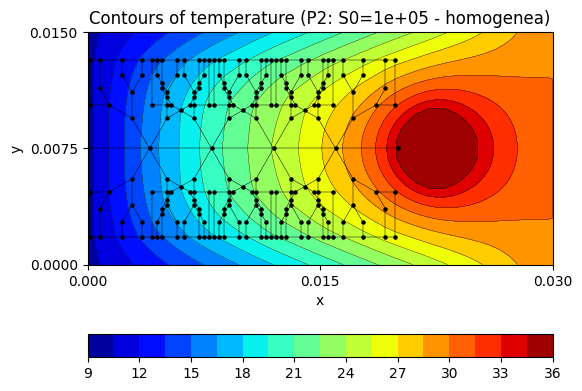

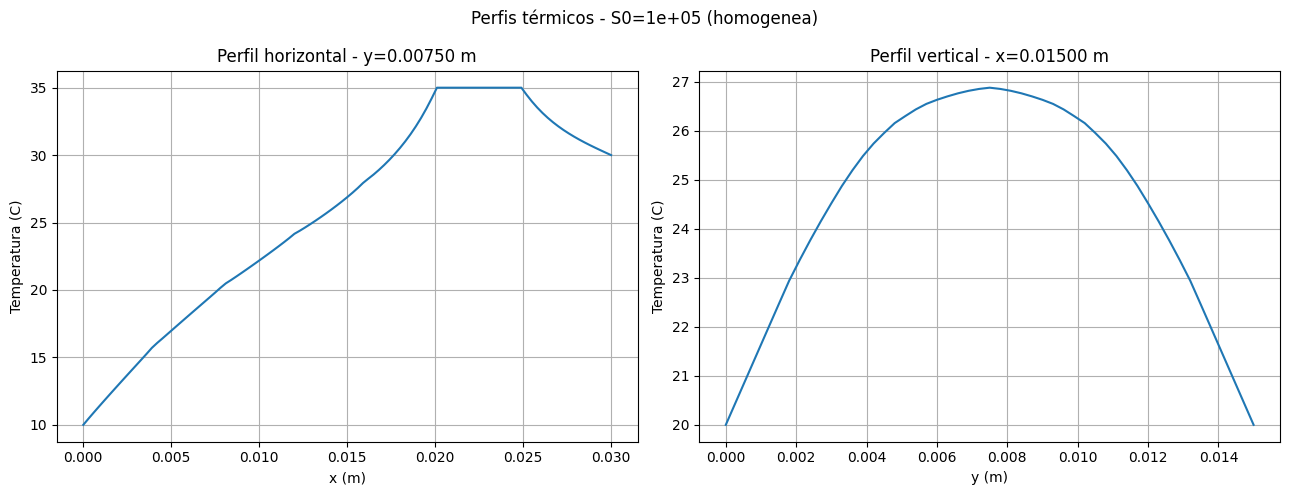

   1.0e+05 |     heterogenea |         60.2301 |         10.0000


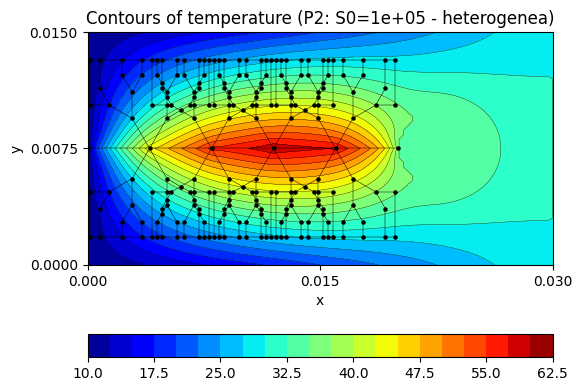

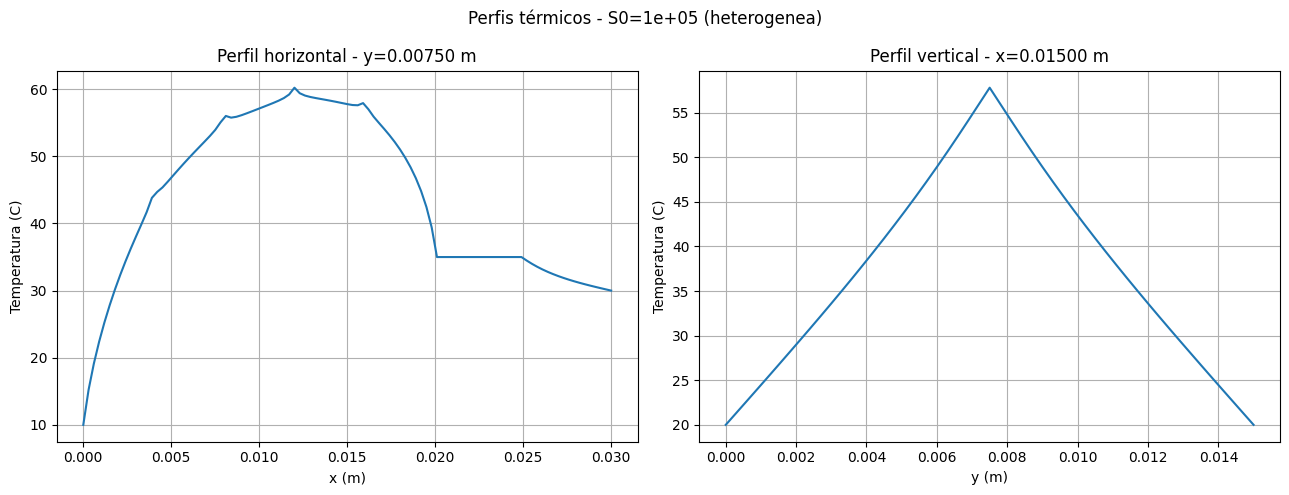

  -1.0e+05 |       homogenea |         35.0000 |          9.9338


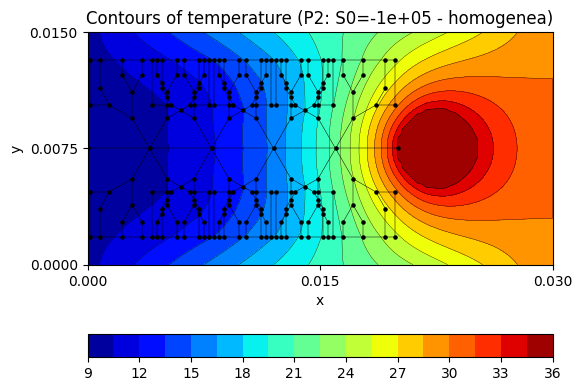

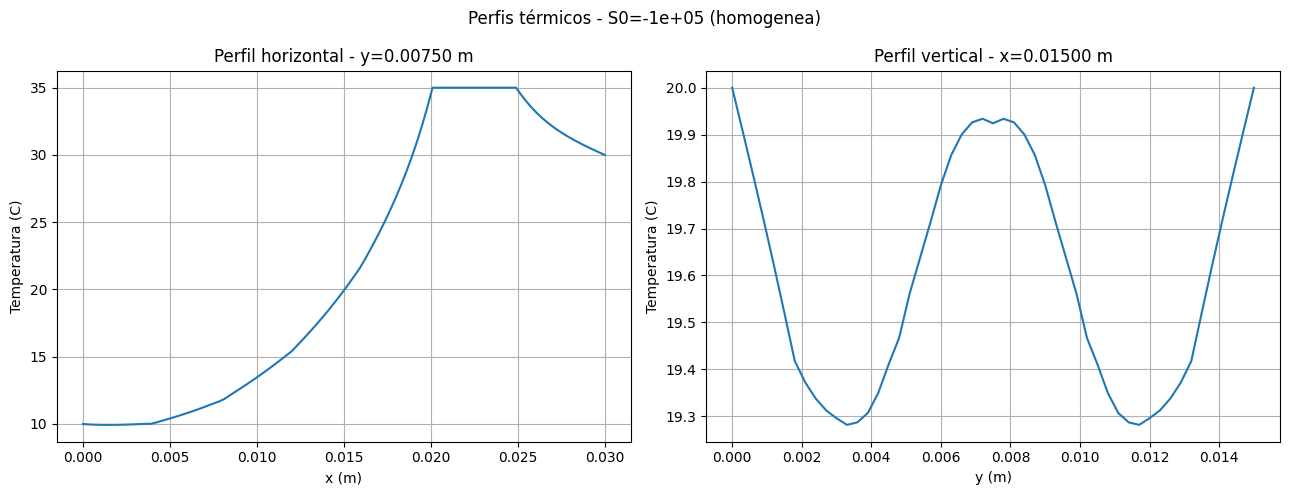

  -1.0e+05 |     heterogenea |         35.0000 |        -23.6939


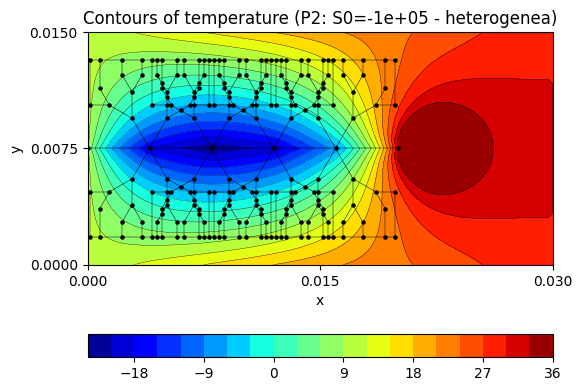

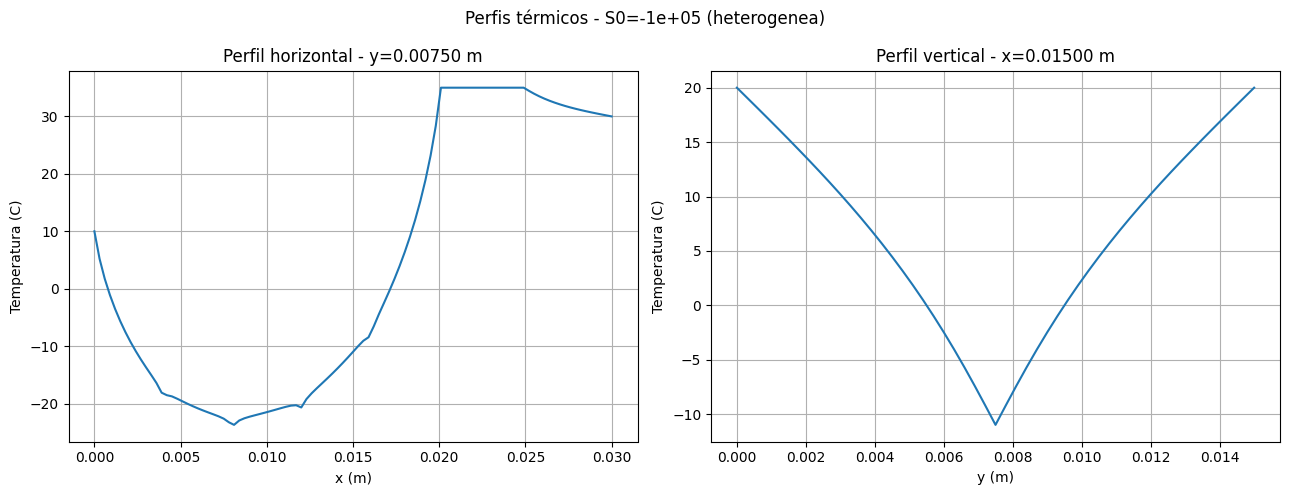

   5.0e+05 |       homogenea |         41.6958 |         10.0000


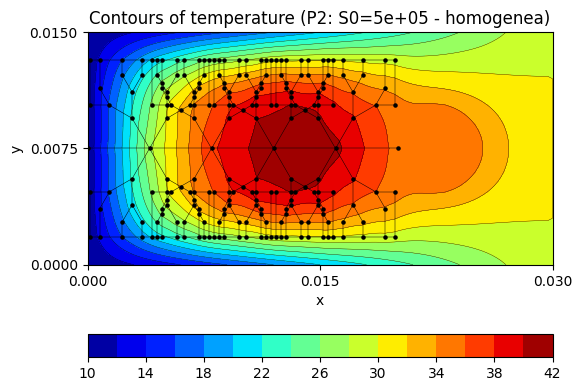

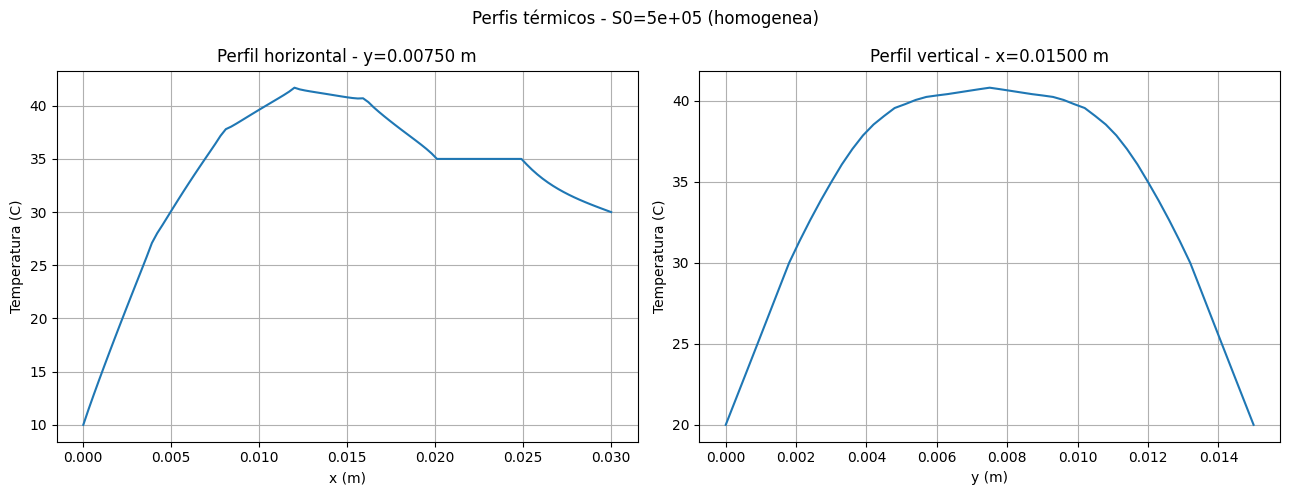

   5.0e+05 |     heterogenea |        222.0156 |         10.0000


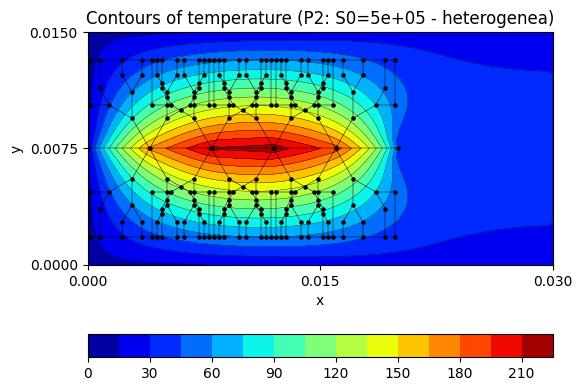

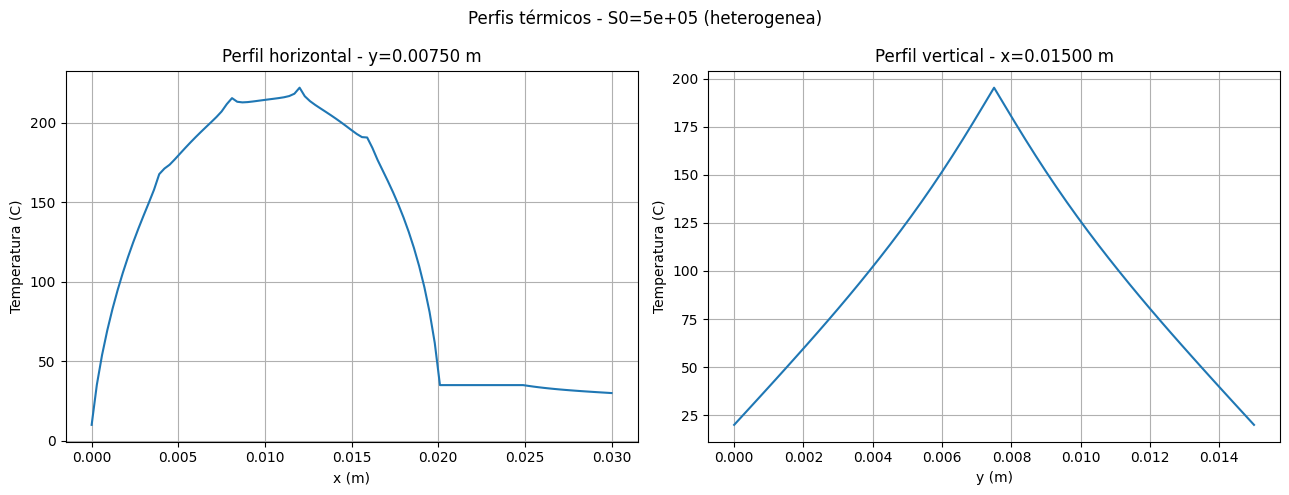

  -5.0e+05 |       homogenea |         35.0000 |         -5.4696


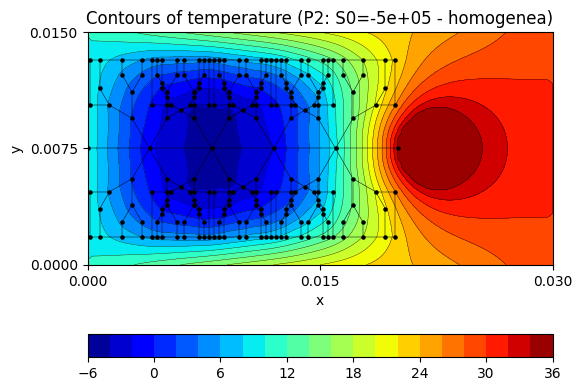

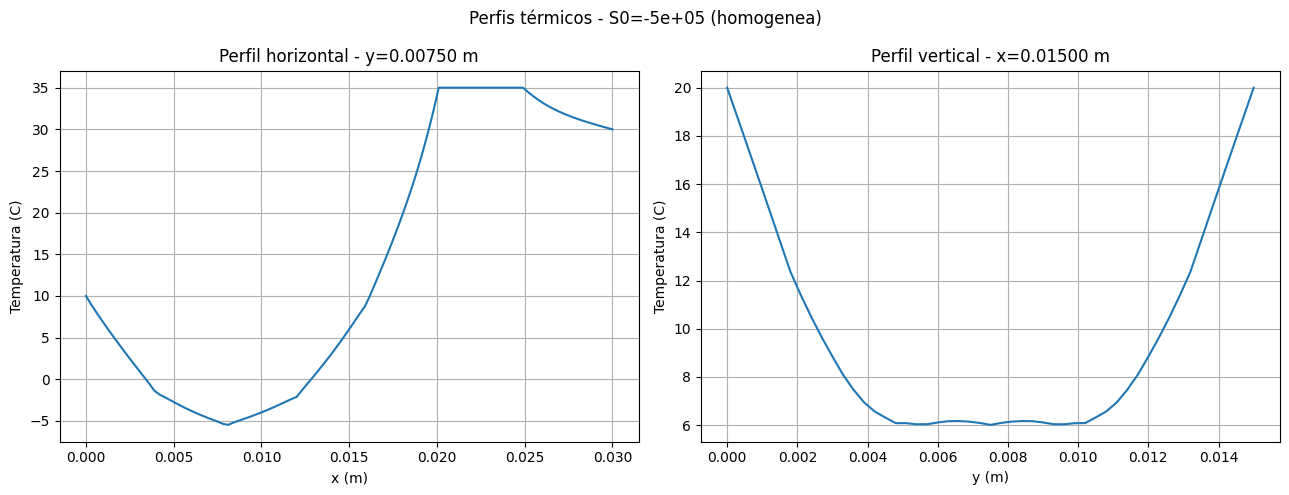

  -5.0e+05 |     heterogenea |         35.0000 |       -183.1244


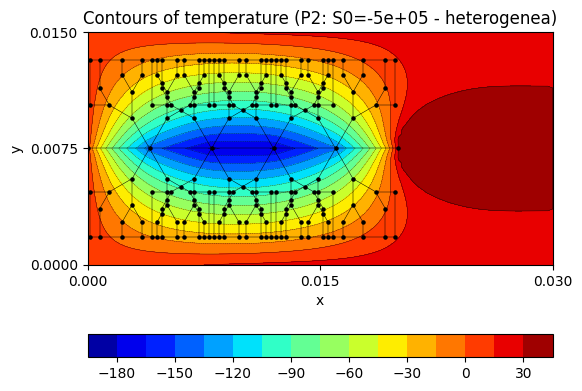

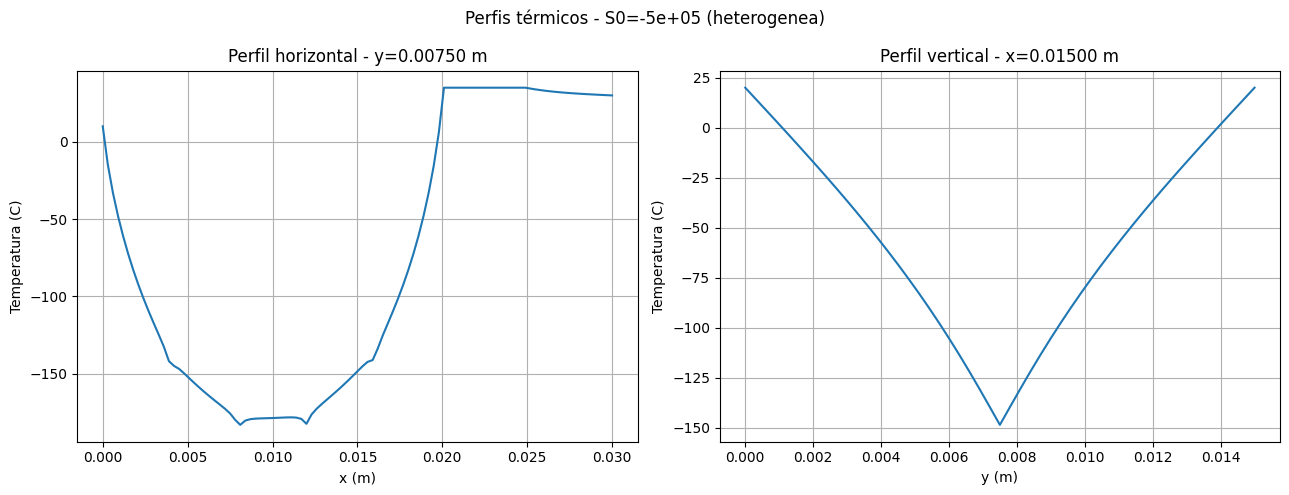

   1.0e+06 |       homogenea |         63.6079 |         10.0000


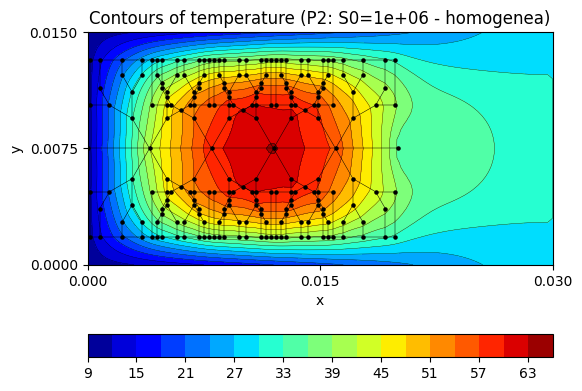

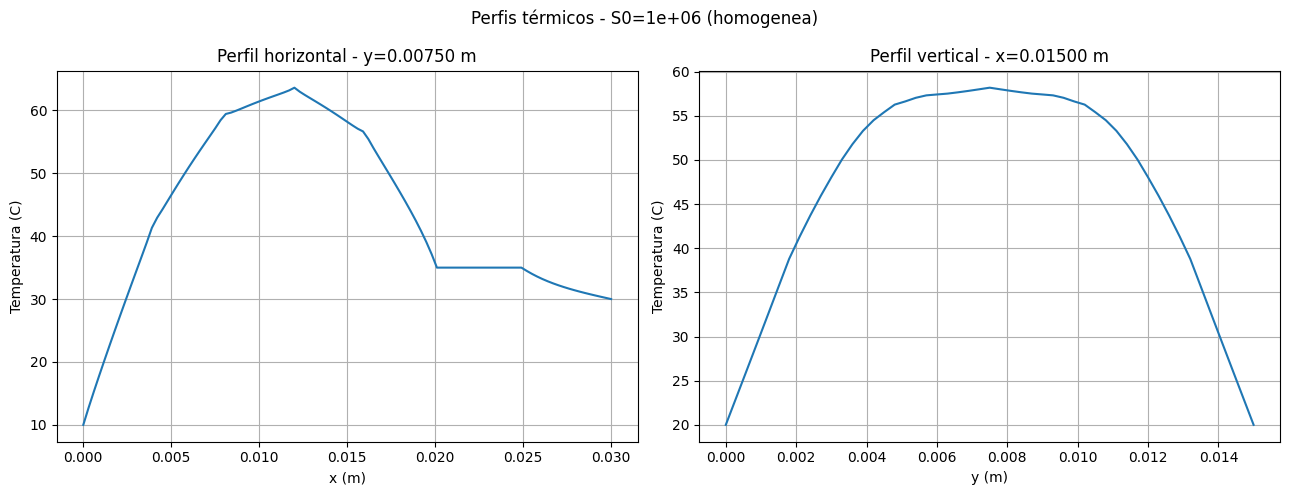

   1.0e+06 |     heterogenea |        424.2475 |         10.0000


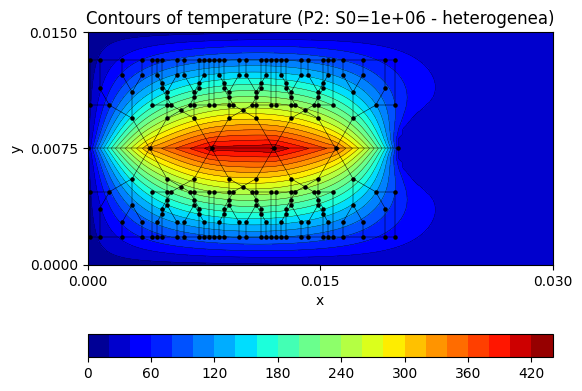

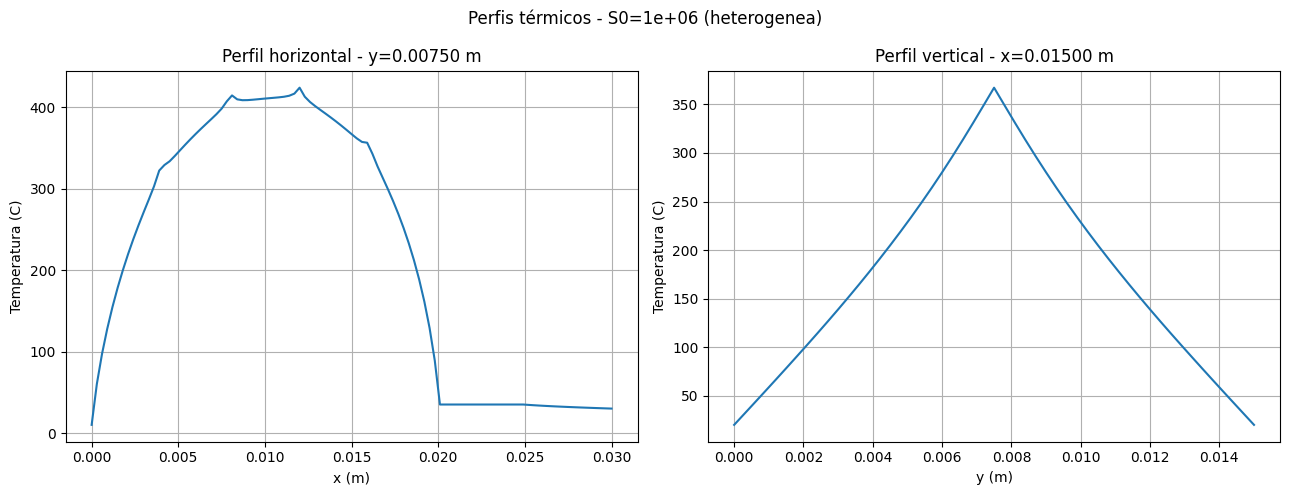

  -1.0e+06 |       homogenea |         35.0000 |        -27.1030


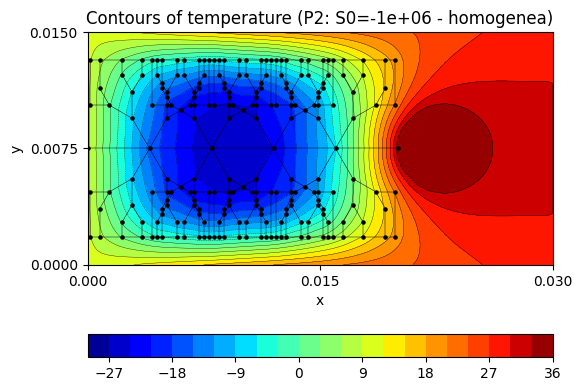

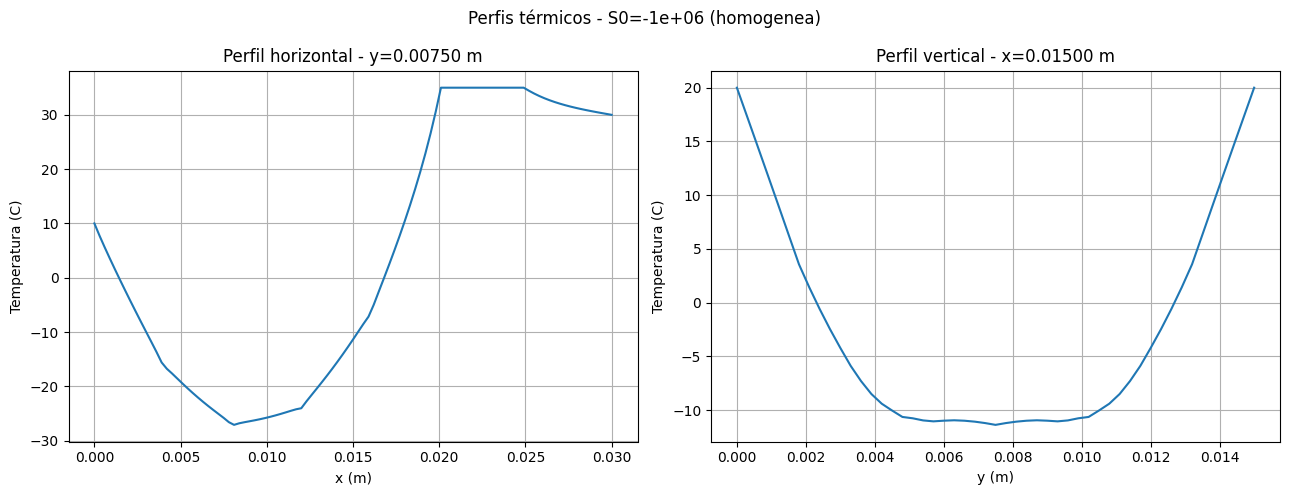

  -1.0e+06 |     heterogenea |         35.0000 |       -384.6801


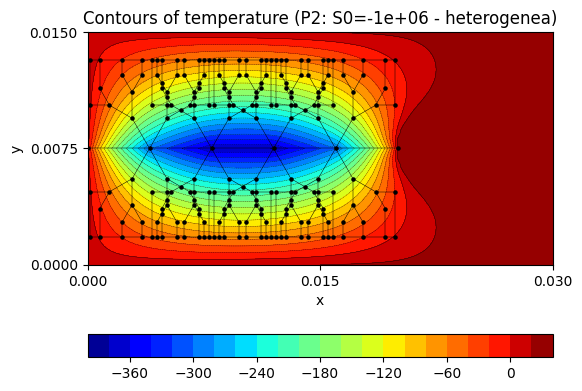

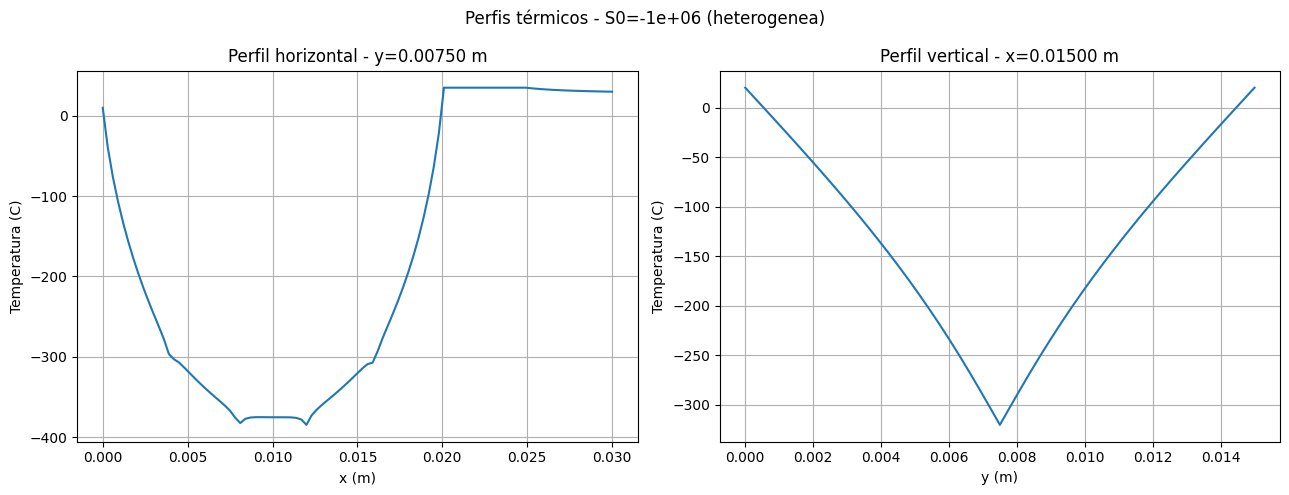

In [17]:
hydraulic_to_thermal = hydraulic_thermal.Hydraulic_to_Thermal_P2_circulo(config)
hydraulic_to_thermal.run_problem2(plot=True);


A tabela produzida ao longo da simulação permite quantificar precisamente o efeito de cada combinação de $S_0$ e distribuição de $I_j$ sobre os extremos de temperatura da placa:

| $S_0$ (W/m³) | Distribuição | $T_{max}$ (°C) | $T_{min}$ (°C) |
|---:|:---|---:|---:|
| $+1{,}0\times10^5$ | homogênea   | 35,00 | 10,00 |
| $+1{,}0\times10^5$ | heterogênea | 60,23 | 10,00 |
| $-1{,}0\times10^5$ | homogênea   | 35,00 | 9,93 |
| $-1{,}0\times10^5$ | heterogênea | 35,00 | -23,69 |
| $+5{,}0\times10^5$ | homogênea   | 41,70 | 10,00 |
| $+5{,}0\times10^5$ | heterogênea | 222,02 | 10,00 |
| $-5{,}0\times10^5$ | homogênea   | 35,00 | -5,47 |
| $-5{,}0\times10^5$ | heterogênea | 35,00 | -183,12 |
| $+1{,}0\times10^6$ | homogênea   | 63,61 | 10,00 |
| $+1{,}0\times10^6$ | heterogênea | 424,25 | 10,00 |
| $-1{,}0\times10^6$ | homogênea   | 35,00 | -27,10 |
| $-1{,}0\times10^6$ | heterogênea | 35,00 | -384,68 |

Nota-se que fontes positivas elevam $T_{max}$ e preservam $T_{min}$ enquanto sumidouros negativos reduzem $T_{min}$ e preservam $T_{max}$. Isso é fisicamente coerente: um termo adicional puramente positivo só pode aumentar a temperatura em relação ao caso sem o termo, logo o mínimo global da placa permanece ancorado nas condições de contorno mais frias ($T_L=10\,$). Simetricamente, um termo puramente negativo só reduz a temperatura, deixando o máximo ancorado na condição de contorno mais quente (a inclusão circular a $T_C=35\,$, ou $T_R=30\,$).

Ainda mais, percebe-se que a distribuição heterogênea amplifica drasticamente o efeito em comparação à homogênea, para a mesma intensidade $S_0$. Por exemplo, em $S_0=+5\times10^5$, a distribuição homogênea eleva $T_{max}$ de $35\,$ para apenas $41{,}70\,$ (um acréscimo de $6{,}7\,$), enquanto a distribuição heterogênea o eleva para $222{,}02\,$ (um acréscimo de 187), quase 28 vezes maior. Isso ocorre porque, na distribuição heterogênea, a intensidade relativa $I_j=100$ concentrada ao longo da espinha central produz um termo fonte muito mais intenso localmente (apesar de $I_j=0{,}1$ atenuar os canais secundários), criando um ponto quente pronunciado, em vez de distribuir a mesma energia total de forma difusa por toda a rede.

Além disso, a resposta em $\Delta T$ não é estritamente proporcional a $S_0$ nos casos homogêneos de baixa intensidade, mas tende à linearidade conforme $|S_0|$ cresce. No caso homogêneo positivo, por exemplo, $\Delta T_{max}$ vale $0$, $6{,}7$ e $28{,}6\,$ para $S_0=10^5,\,5\times10^5,\,10^6$, respectivamente, claramente não proporcional entre o primeiro e o segundo ponto, mas a razão entre o segundo e o terceiro ($28{,}6/6{,}7\approx4{,}3$) já se aproxima mais da razão esperada entre as intensidades ($10^6/5\times10^5=2$). Esse comportamento sugere que, para intensidades pequenas, o efeito da reação é parcialmente "absorvido" pela dinâmica de condução já existente (dominada pelas condições de contorno fixas e pela fonte de calor original da placa, $5\times10^5\,\text{W}\cdot\text{m}^{-3}$), e só se torna dominante (e portanto aproximadamente linear, como esperado de uma equação de condução linear com termo fonte aditivo), quando $S_0$ é grande o suficiente para superar essa dinâmica de base. Esse efeito de quase-linearização em alta intensidade é ainda mais nítido na distribuição heterogênea negativa: a razão entre $\Delta T_{min}$ em $S_0=-10^6$ e $S_0=-5\times10^5$ é $394{,}68/193{,}12\approx2{,}04$, muito próxima da razão de intensidades ($2{,}0$) esperada em regime linear.

Observa-se também que os sumidouros (S₀ negativo) produzem, em módulo, desvios de temperatura ainda mais extremos que as fontes de mesma magnitude na distribuição heterogênea. Por exemplo, $\Delta T_{min} \approx -384{,}7\,$ para $S_0=-10^6$ heterogêneo, contra $\Delta T_{max} \approx +389{,}25\,$ para $S_0=+10^6$ heterogêneo, valores de magnitude muito próxima, como esperado de uma equação de condução linear (onde a resposta a $-S_0$ deveria ser, em primeira aproximação, o negativo exato da resposta a $+S_0$, já que o termo fonte entra aditivamente no sistema linear). 

Esses resultados evidenciam que, caso reações químicas concentradas (como as representadas pela distribuição heterogênea) venham a ocorrer no canal principal da rede, o impacto térmico sobre a placa pode ser ordens de grandeza mais severo do que o previsto por um
modelo que assuma, por simplificação, uma distribuição homogênea da reação ao longo de toda a rede.
